In [1]:
# Setup and helper functions moved to external module
from equations_file import *

# If you change the external module and want live reload during development, uncomment:
# %load_ext autoreload
# %autoreload 2

In [2]:
with fitsio.FITS(galah_Gaia_fits) as hdul1:
    data_1 = hdul1[1].read()
galah_Gaia_raw = pd.DataFrame(data_1)
galah_Gaia_raw = ensure_native_endian(galah_Gaia_raw)

In [3]:
GSE_vs_Halo_energy_test_file = '/Users/simoncorrera/Desktop/MQ NGC3201 project copy/sequoia paper matieral/Energy_Test_results/GSE_P_Halo_elmlist_18_energy_test.csv'
GSE_vs_Halo_energy_test = pd.read_csv(GSE_vs_Halo_energy_test_file)

Seq_con_vs_GSE_energy_test = '/Users/simoncorrera/Desktop/MQ NGC3201 project copy/sequoia paper matieral/Energy_Test_results/Seq_con_GSE_elmlist_18_energy_test.csv'
Seq_con_vs_GSE_energy_test = pd.read_csv(Seq_con_vs_GSE_energy_test)

Seq_Tham_vs_GSE_energy_test = '/Users/simoncorrera/Desktop/MQ NGC3201 project copy/sequoia paper matieral/Energy_Test_results/Seq_Tham_GSE_elmlist_18_energy_test.csv'
Seq_Tham_vs_GSE_energy_test = pd.read_csv(Seq_Tham_vs_GSE_energy_test)

Seq_con_vs_Halo_energy_test = '/Users/simoncorrera/Desktop/MQ NGC3201 project copy/sequoia paper matieral/Energy_Test_results/Seq_con_P_Halo_elmlist_18_energy_test.csv'
Seq_con_vs_Halo_energy_test = pd.read_csv(Seq_con_vs_Halo_energy_test)

Seq_Tham_vs_Halo_energy_test = '/Users/simoncorrera/Desktop/MQ NGC3201 project copy/sequoia paper matieral/Energy_Test_results/Seq_Tham_P_Halo_elmlist_18_energy_test.csv'
Seq_Tham_vs_Halo_energy_test = pd.read_csv(Seq_Tham_vs_Halo_energy_test)

Seq_con_vs_Seq_Tham_energy_test = '/Users/simoncorrera/Desktop/MQ NGC3201 project copy/sequoia paper matieral/Energy_Test_results/Seq_con_Seq_Tham_elmlist_18_energy_test.csv'
Seq_con_vs_Seq_Tham_energy_test = pd.read_csv(Seq_con_vs_Seq_Tham_energy_test)


In [4]:
galah_Gaia = galah_Gaia_raw[(galah_Gaia_raw['snr_px_ccd3'] > 30)       # Kushniruk 2026 also has cuts in log g and temp. I wonder if I should as well
                        & (galah_Gaia_raw['flag_sp'] == 0)
                        & (galah_Gaia_raw['flag_fe_h'] == 0)
                        & (galah_Gaia_raw['e_fe_h'] < 0.2)
                        & (galah_Gaia_raw['flag_sp_fit'] == 0)
                        & (galah_Gaia_raw['flag_red'] == 0)
                        & (galah_Gaia_raw['ruwe'] < 1.4)
                        & (galah_Gaia_raw['logg'] < 3.5)
                        & (galah_Gaia_raw['teff'] > 4000)
                        & (galah_Gaia_raw['teff'] < 6500)
                        # & (galah_Gaia_raw['flag_mg_fe'] == 0)
                        # & (galah_Gaia_raw['flag_na_fe'] == 0)
                        # & (galah_Gaia_raw['flag_cu_fe'] == 0)
                        # & (galah_Gaia_raw['fe_h'] < -0.8)
                        # & (galah_Gaia_raw['fe_h'] < -1.25)
                        # & (galah_Gaia_raw['fe_h'] > -1.8)
                        # & (galah_Gaia_raw['ti_fe'] > 0.25)
                        
                        & (galah_Gaia_raw['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main',
                                                               'k2_hermes', 'galah_phase2', 'tess_hermes'
                                                               ]))
                        & (galah_Gaia_raw['radial_velocity'].notnull())
                        & (galah_Gaia_raw['ra_gaia'].notnull())
                        & (galah_Gaia_raw['dec_gaia'].notnull())
                        & (galah_Gaia_raw['pmra_gaia'].notnull())
                        & (galah_Gaia_raw['pmdec_gaia'].notnull())
                        & (galah_Gaia_raw['parallax_gaia'] > 0)
                        
    ]

print(f"Number of stars after cuts: {len(galah_Gaia)}")

Number of stars after cuts: 159474


In [93]:
NGC3201_galah = pd.merge( galah_Gaia, Vmans_NGC3201_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')
NGC5139_galah = pd.merge( galah_Gaia, Vmans_NGC5139_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')
NGC1851_galah = pd.merge( galah_Gaia, Vmans_NGC1851_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')   
NGC0104_galah = pd.merge( galah_Gaia, Vmans_NGC0104_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')

galah_Kushniruk_GSE = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])-35)**2) / (17.5**2)) + (((galah_Gaia['jphi'] + 130)**2) / (250**2)) < 1)
                                #  & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                 & (galah_Gaia_raw['flag_mg_fe'] == 0)
                                 & (galah_Gaia_raw['flag_na_fe'] == 0)
                                 & (galah_Gaia_raw['flag_cu_fe'] == 0)
                                 & ((galah_Gaia_raw['mg_fe'] - galah_Gaia_raw['cu_fe']) - ((1.06923) * galah_Gaia_raw['na_fe']) > 0.40150)
                                 ]

# Kushniruk et al . 2026 https://doi.org/10.1051/0004-6361/202451201
galah_Kushniruk_Thamnos1 = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])- 13.5)**2) / (4.0**2)) + (((galah_Gaia['jphi'] + 600)**2) / (350**2)) < 1)
                                        # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                        # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                        # & (galah_Gaia['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main']))
                                        & (galah_Gaia_raw['fe_h'] < -0.8)
                                      ]

galah_Kushniruk_Thamnos2 = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])-8.6)**2) / (3.5**2)) + (((galah_Gaia['jphi'] + 1184)**2) / (175**2)) < 1)
                                        # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                        # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                        # & (galah_Gaia['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main']))
                                        & (galah_Gaia_raw['fe_h'] < -0.8)
                                      ]

# Feuillet et al. 2021 https://doi.org/10.1093/mnras/stab2614
galah_Gaia_GSE = galah_Gaia[GSE_cuts_Diane_2021(galah_Gaia)
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                            & (galah_Gaia_raw['fe_h'] < -0.8)
                            ]

# Feuillet et al. 2021 https://doi.org/10.1093/mnras/stab2614
galah_Gaia_Sequoia = galah_Gaia[Sequoia_cuts_Diane_2021(galah_Gaia)
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                            & (galah_Gaia_raw['fe_h'] < -0.8)
                            # & (galah_Gaia_raw['fe_h'] > -1.3)

                            # & (galah_Gaia_raw['y_fe'] < 0.8)
]

# Feuillet et al. 2021 https://doi.org/10.1093/mnras/stab2614
galah_Gaia_Sequoia_p_thamnos = galah_Gaia[Sequoia_cuts_Diane_2021(galah_Gaia)
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                            & (galah_Gaia_raw['fe_h'] < -0.8)
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia['gaiadr3_source_id']))

                            # & (galah_Gaia_raw['y_fe'] < 0.8)
]

galah_Gaia_Halo = galah_Gaia[(np.sqrt((galah_Gaia['vphi']-230)**2 + (galah_Gaia['vr'])**2 + (galah_Gaia['vz'])**2) > 230) # Koppelman et al. 2019  https://doi.org/10.1051/0004-6361/201936738
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id'])) 
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia['gaiadr3_source_id'])) 
                            # & (galah_Gaia_raw['fe_h'] < -1.1)
                            # & (galah_Gaia_raw['fe_h'] > -1.9)
                            & (galah_Gaia_raw['fe_h'] < -0.8)
                             ]


/var/folders/k3/63pgq9cd0rvg7fhy2d0q_sj40000gp/T/ipykernel_34894/506479255.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  galah_Kushniruk_GSE = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])-35)**2) / (17.5**2)) + (((galah_Gaia['jphi'] + 130)**2) / (250**2)) < 1)

/var/folders/k3/63pgq9cd0rvg7fhy2d0q_sj40000gp/T/ipykernel_34894/506479255.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  galah_Kushniruk_Thamnos1 = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])- 13.5)**2) / (4.0**2)) + (((galah_Gaia['jphi'] + 600)**2) / (350**2)) < 1)

/var/folders/k3/63pgq9cd0rvg7fhy2d0q_sj40000gp/T/ipykernel_34894/506479255.py:22: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  galah_Kushniruk_Thamnos2 = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])-8.6)**2) / (3.5**2)) + (((galah_Gaia['jphi'] + 1184)**2) / (175**2)) < 1)

/var/folders/k3/63pgq9cd0rvg7fhy2d0q_sj40000gp/T/ipykernel_34894/506479255.py:30: UserWarning: Bo

In [94]:
Halo_Pradosh_galah_Gaia = galah_Gaia[
                                            (galah_Gaia['fe_h'] < -0.8)&
                                            (galah_Gaia['ti_fe'] > 0.25)
                                            & (galah_Gaia['flag_ti_fe'] == 0)
                                            & (galah_Gaia['Lz'] > -1500)
                                            & (galah_Gaia['Lz'] < 1500)
                                            & (galah_Gaia['ecc_gaia'] > 0.5)
                                            & (galah_Gaia['ecc_gaia'] < 0.8)
                                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                                            # & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC3201_new_ratios['gaiadr3_source_id']))
                                            # & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC5139_new_ratios['gaiadr3_source_id']))
                                            ]

thickdisk_galah_Gaia = galah_Gaia[(galah_Gaia['fe_h'] < -0.8)
                                                 & (galah_Gaia['ti_fe'] > 0.25)
                                                 & (galah_Gaia['Lz'] > 0)
                                                 & (galah_Gaia['ecc_gaia'] < 0.5)
                                                #  & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                                                # & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC3201_new_ratios['gaiadr3_source_id']))
                                                # & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC5139_new_ratios['gaiadr3_source_id']))
                                            ]
print(len(Halo_Pradosh_galah_Gaia))
print(len(thickdisk_galah_Gaia))

galah_Gaia_Halo = Halo_Pradosh_galah_Gaia

1834
2659


In [95]:
galah_Gaia_else = galah_Gaia_raw[(galah_Gaia_raw['snr_px_ccd3'] > 30)       # Kushniruk 2026 also has cuts in log g and temp. I wonder if I should as well
                        & (galah_Gaia_raw['flag_sp'] == 0)
                        & (galah_Gaia_raw['flag_fe_h'] == 0)
                        & (galah_Gaia_raw['e_fe_h'] < 0.2)
                        & (galah_Gaia_raw['flag_sp_fit'] == 0)
                        & (galah_Gaia_raw['flag_red'] == 0)
                        & (galah_Gaia_raw['ruwe'] < 1.4)
                        & (galah_Gaia_raw['logg'] < 3.5)
                        & (galah_Gaia_raw['teff'] > 4000)
                        & (galah_Gaia_raw['teff'] < 6500)
                        # & (galah_Gaia_raw['fe_h'] < -0.75)
                        # & (~galah_Gaia_raw['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                        # & (~galah_Gaia_raw['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id'])) 
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(galah_Gaia_GSE['gaiadr3_source_id']))
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(galah_Gaia_Sequoia['gaiadr3_source_id'])) 
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(galah_Gaia_Halo['gaiadr3_source_id']))
                        & (galah_Gaia_raw['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main',
                                                               'k2_hermes', 'galah_phase2', 'tess_hermes'
                                                               ]))
    ]

In [96]:
"""Remember that the Pradosh Halo Is writen to override the other characterization for the Halo. I did this
because it was easier to do than to rewrite code for the Pradosh Halo, but I need to call it out if I want to ever use the other one"""

'Remember that the Pradosh Halo Is writen to override the other characterization for the Halo. I did this\nbecause it was easier to do than to rewrite code for the Pradosh Halo, but I need to call it out if I want to ever use the other one'

In [97]:
print(f'len(NGC3201_galah): {len(NGC3201_galah)}')
print(f'len(NGC5139_galah): {len(NGC5139_galah)}')
print(f'len(NGC1851_galah): {len(NGC1851_galah)}')
print(f'len(NGC0104_galah): {len(NGC0104_galah)}')
print(f'len(galah_Kushniruk_GSE): {len(galah_Kushniruk_GSE)}')
print(f'len(galah_Kushniruk_Thamnos1): {len(galah_Kushniruk_Thamnos1)}')
print(f'len(galah_Kushniruk_Thamnos2): {len(galah_Kushniruk_Thamnos2)}')
print(f'len(galah_Gaia_GSE): {len(galah_Gaia_GSE)}')
print(f'len(galah_Gaia_Sequoia): {len(galah_Gaia_Sequoia)}')
print(f'len(galah_Gaia_Sequoia): {len(Halo_Pradosh_galah_Gaia)}')
print(f'len(galah_Gaia_Halo): {len(galah_Gaia_Halo)}')
print(f'len(galah_Gaia_Halo): {len(galah_Gaia_Halo)}')
print(f'len(galah_Gaia_else): {len(galah_Gaia_else)}')

len(NGC3201_galah): 0
len(NGC5139_galah): 3
len(NGC1851_galah): 0
len(NGC0104_galah): 132
len(galah_Kushniruk_GSE): 745
len(galah_Kushniruk_Thamnos1): 211
len(galah_Kushniruk_Thamnos2): 19
len(galah_Gaia_GSE): 844
len(galah_Gaia_Sequoia): 126
len(galah_Gaia_Sequoia): 1834
len(galah_Gaia_Halo): 1834
len(galah_Gaia_Halo): 1834
len(galah_Gaia_else): 157441


In [ ]:
galah_Gaia_else_C = "#363535"
Sequoia_C = "#af0606"
Sequoia_C_2 = "#e018ff"

GSE_C = "#16b823d8"
Halo_C = "#0e35e2"
thamnos_1_C = "#96bd0b"
thamnos_2_C = "#47F1C4"

Text(0.02, 0.98, 'D')

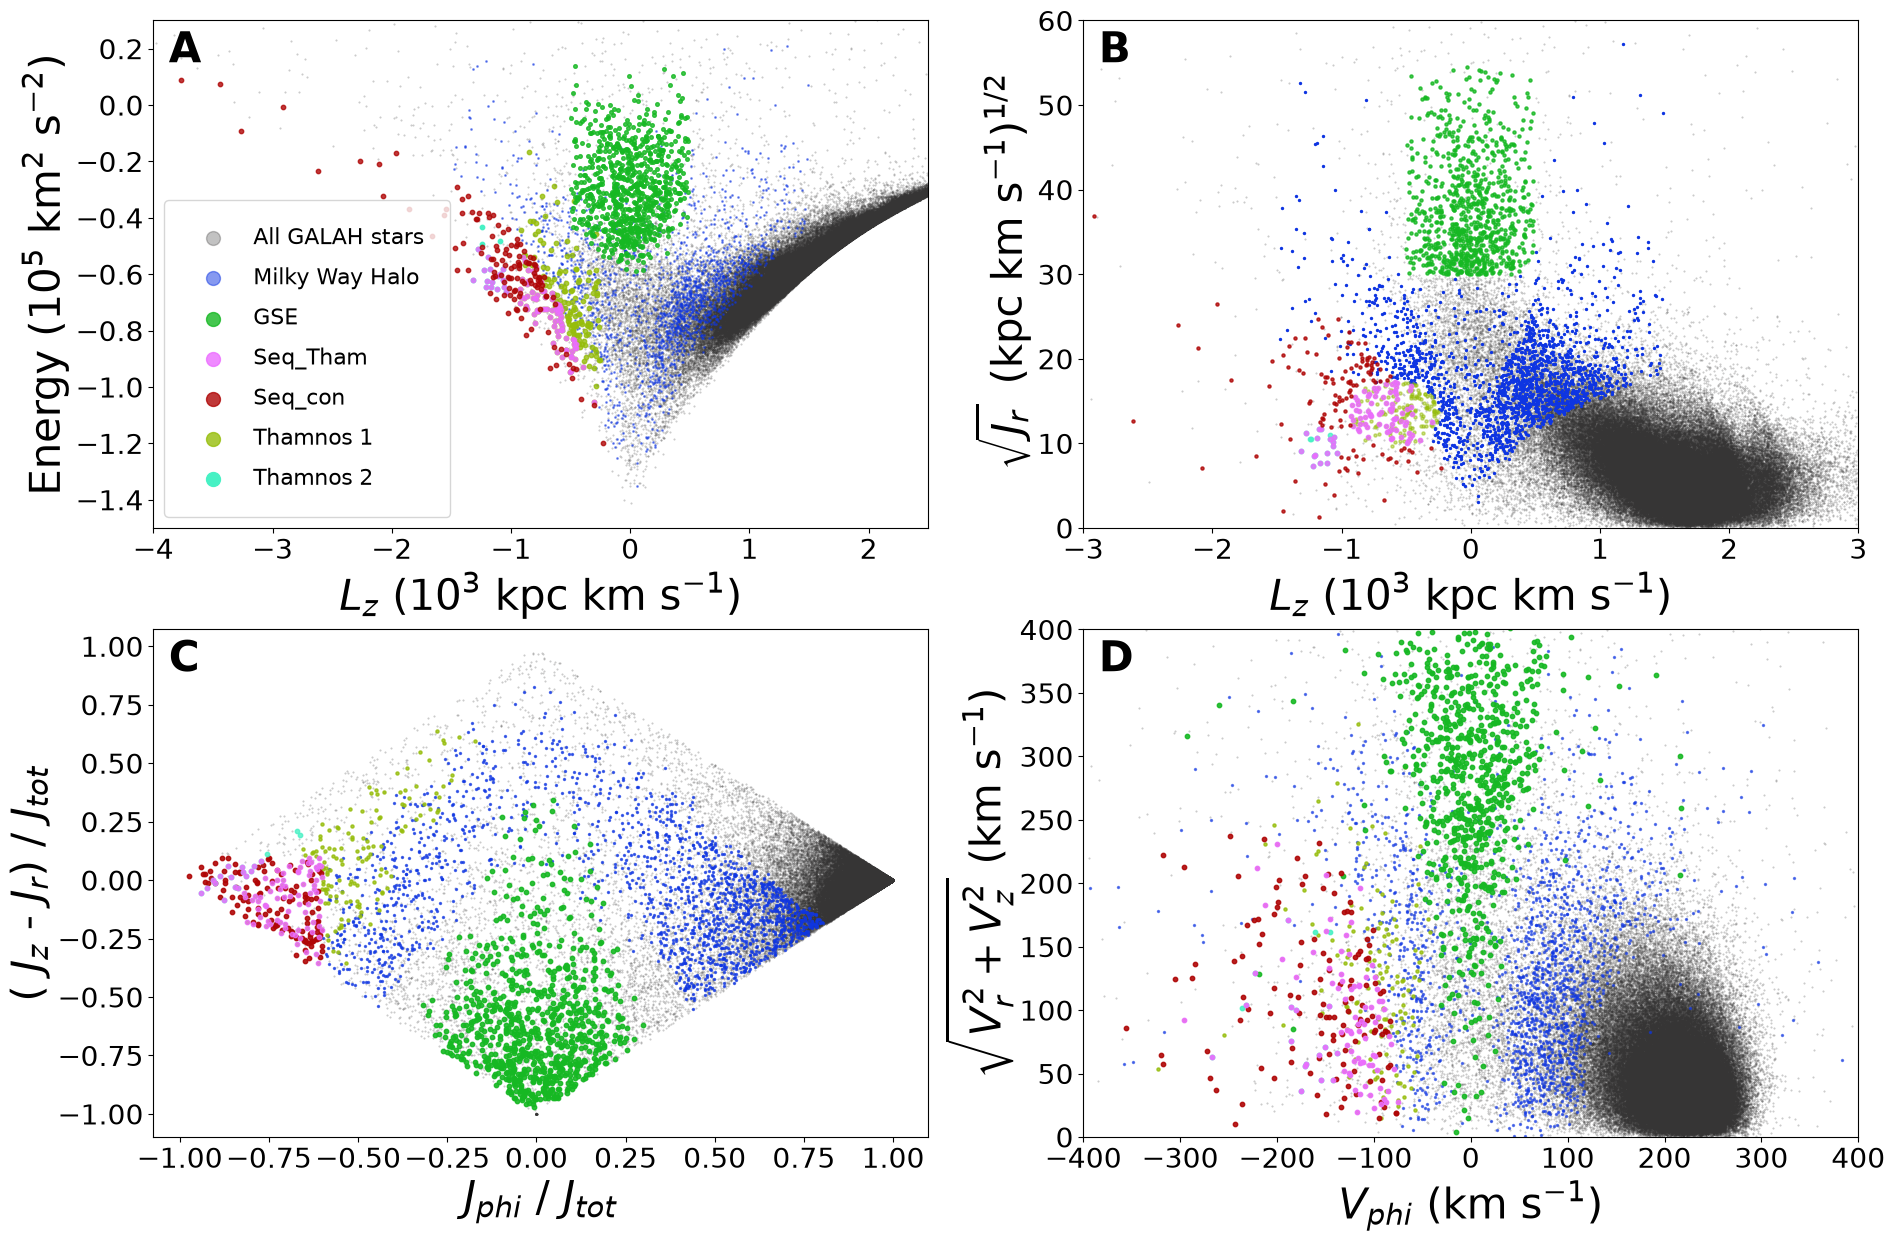

In [149]:
fig, ax = plt.subplots(2, 2, sharex=False, sharey=False, figsize=(22, 14.5)) # (rows, colums, share y axis and/or share x axis)
# fig.patch.set_alpha(0) # this can make the image transpearent.
fontsize = 30
labelsize = 20

ax[0,0].scatter(galah_Gaia_else['jphi']/1e3, galah_Gaia_else['energy']/1e5, label = 'All GALAH stars', s = 0.2, alpha = 0.3, c = galah_Gaia_else_C)
ax[0,0].scatter(galah_Gaia_Halo['jphi']/1e3, galah_Gaia_Halo['energy']/1e5, label = 'Milky Way Halo', s = 1, alpha = 0.5, c = Halo_C)
ax[0,0].scatter(galah_Kushniruk_Thamnos1['jphi']/1e3, galah_Kushniruk_Thamnos1['energy']/1e5, label = 'Thamnos 1', s = 10, alpha = 0.8, c = thamnos_1_C)
ax[0,0].scatter(galah_Kushniruk_Thamnos2['jphi']/1e3, galah_Kushniruk_Thamnos2['energy']/1e5, label = 'Thamnos 2', s = 10, alpha = 1.0, c = thamnos_2_C)
ax[0,0].scatter(galah_Gaia_GSE['jphi']/1e3, galah_Gaia_GSE['energy']/1e5, label = 'GSE', s = 7, alpha = 0.8, c = GSE_C)
ax[0,0].scatter(galah_Gaia_Sequoia_p_thamnos['jphi']/1e3, galah_Gaia_Sequoia_p_thamnos['energy']/1e5, label = 'Seq_Tham', s = 10, alpha = 0.8, c = Sequoia_C_2)
ax[0,0].scatter(galah_Gaia_Sequoia['jphi']/1e3, galah_Gaia_Sequoia['energy']/1e5, label = 'Seq_con', s = 10, alpha = 0.8, c = Sequoia_C)
ax[0,0].set_xlim(-4000/1e3, 2500/1e3)
ax[0,0].set_ylim(-150000/1e5,30000/1e5)
ax[0,0].tick_params(axis='x', labelsize = labelsize)
ax[0,0].tick_params(axis='y', labelsize = labelsize)
ax[0,0].set_xlabel(r'$L_z$ ($10^3$ kpc km s$^{-1}$)', fontsize = fontsize)
ax[0,0].set_ylabel(r'Energy ($10^5$ km$^2$ s$^{-2}$)', fontsize = fontsize)
ax[0,0].text(0.02, 0.98, 'A', transform=ax[0,0].transAxes, fontsize=fontsize, fontweight='bold', va='top', ha='left')

handles, labels = ax[0,0].get_legend_handles_labels()

# Desired legend order
order = [
    labels.index('All GALAH stars'),
    labels.index('Milky Way Halo'),
    labels.index('GSE'),
    labels.index('Seq_Tham'),
    labels.index('Seq_con'),
    labels.index('Thamnos 1'),
    labels.index('Thamnos 2')
]

leg = ax[0,0].legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    fontsize=16,
    labelspacing=0.8,
    borderpad=1.2
)

for handle in leg.legend_handles:
    try:
        handle.set_sizes([100])
    except Exception:
        pass
###########################################################################################
ax[0,1].scatter(galah_Gaia_else['jphi']/1e3, np.sqrt(galah_Gaia_else['jr']), label = 'All Galah stars', s = 0.2, alpha = 0.3, c = galah_Gaia_else_C)
ax[0,1].scatter(galah_Gaia_Halo['jphi']/1e3, np.sqrt(galah_Gaia_Halo['jr']), label = 'Halo', s = 2, alpha = 1.0, c = Halo_C)
ax[0,1].scatter(galah_Kushniruk_Thamnos1['jphi']/1e3, np.sqrt(galah_Kushniruk_Thamnos1['jr']), label = 'Thamnos 1', s = 5, alpha = 0.5, c = thamnos_1_C)
ax[0,1].scatter(galah_Kushniruk_Thamnos2['jphi']/1e3, np.sqrt(galah_Kushniruk_Thamnos2['jr']), label = 'Thamnos 2', s = 10, alpha = 0.8, c = thamnos_2_C)
ax[0,1].scatter(galah_Gaia_Sequoia_p_thamnos['jphi']/1e3, np.sqrt(galah_Gaia_Sequoia_p_thamnos['jr']), label = 'Seq_Tham', s = 10, alpha = 0.8, c = Sequoia_C_2)
ax[0,1].scatter(galah_Gaia_GSE['jphi']/1e3, np.sqrt(galah_Gaia_GSE['jr']), label = 'GSE', s = 5, alpha = 0.8, c = GSE_C)
ax[0,1].scatter(galah_Gaia_Sequoia['jphi']/1e3, np.sqrt(galah_Gaia_Sequoia['jr']), label = 'Sequoia', s = 5, alpha = 0.8, c = Sequoia_C)
ax[0,1].set_xlim(-3000/1e3, 3000/1e3)
ax[0,1].set_ylim(0,60)
ax[0,1].tick_params(axis='x', labelsize = labelsize)
ax[0,1].tick_params(axis='y', labelsize = labelsize)
ax[0,1].set_xlabel(r'$L_z$ ($10^3$ kpc km s$^{-1}$)', fontsize = fontsize)
ax[0,1].set_ylabel(r'$\,\sqrt{J_r}\,$ (kpc km s$^{-1}$)$^{1/2}$', fontsize = fontsize);
ax[0,1].text(0.02, 0.98, 'B', transform=ax[0,1].transAxes, fontsize=fontsize, fontweight='bold', va='top', ha='left')

###########################################################################################
ax[1,0].scatter( galah_Gaia_else['jphi']/ galah_Gaia_else['jtot'], (galah_Gaia_else['jz'] - galah_Gaia_else['jr'])/galah_Gaia_else['jtot'], label = 'All Galah stars', s = 0.2, c = galah_Gaia_else_C, alpha = 0.3)
ax[1,0].scatter( galah_Gaia_Halo['jphi']/ galah_Gaia_Halo['jtot'], (galah_Gaia_Halo['jz'] - galah_Gaia_Halo['jr'])/galah_Gaia_Halo['jtot'], label = 'Milky Way Halo', s = 2, c = Halo_C, alpha = 0.7)
ax[1,0].scatter( galah_Kushniruk_Thamnos1['jphi']/ galah_Kushniruk_Thamnos1['jtot'], (galah_Kushniruk_Thamnos1['jz'] - galah_Kushniruk_Thamnos1['jr'])/galah_Kushniruk_Thamnos1['jtot'], label = 'Thamnos 1', c = thamnos_1_C, s = 5, alpha = 0.8)
ax[1,0].scatter( galah_Gaia_GSE['jphi']/ galah_Gaia_GSE['jtot'], (galah_Gaia_GSE['jz'] - galah_Gaia_GSE['jr'])/galah_Gaia_GSE['jtot'], label = 'GSE', c = GSE_C, s = 10, alpha  = 0.9)
ax[1,0].scatter( galah_Gaia_Sequoia['jphi']/ galah_Gaia_Sequoia['jtot'], (galah_Gaia_Sequoia['jz'] - galah_Gaia_Sequoia['jr'])/galah_Gaia_Sequoia['jtot'], label = 'Sequoia', c = Sequoia_C, s = 10, alpha = 0.9)
ax[1,0].scatter( galah_Kushniruk_Thamnos2['jphi']/ galah_Kushniruk_Thamnos2['jtot'], (galah_Kushniruk_Thamnos2['jz'] - galah_Kushniruk_Thamnos2['jr'])/galah_Kushniruk_Thamnos2['jtot'], label = 'Thamnos 2', c = thamnos_2_C, s = 10, alpha = 0.8)
ax[1,0].scatter( galah_Gaia_Sequoia_p_thamnos['jphi']/ galah_Gaia_Sequoia_p_thamnos['jtot'], (galah_Gaia_Sequoia_p_thamnos['jz'] - galah_Gaia_Sequoia_p_thamnos['jr'])/galah_Gaia_Sequoia_p_thamnos['jtot'], label = 'Seq_Tham', c = Sequoia_C_2, s = 10, alpha = 0.8)
ax[1,0].set_xlabel(r'$J_{phi}$ / $J_{tot}$', fontsize = fontsize)
ax[1,0].set_ylabel(r'( $J_z$ - $J_r$) / $J_{tot}$', fontsize = fontsize)
ax[1,0].text(0.02, 0.98, 'C', transform=ax[1,0].transAxes, fontsize=fontsize, fontweight='bold', va='top', ha='left')
ax[1,0].tick_params(axis='x', labelsize = labelsize)
ax[1,0].tick_params(axis='y', labelsize = labelsize)
############################################################################################
ax[1,1].scatter(galah_Gaia_else['vphi'], np.sqrt((galah_Gaia_else['vr'])**2 + (galah_Gaia_else['vz'])**2), label = 'All Galah stars', s = 0.2, alpha = 0.3, c = galah_Gaia_else_C)
ax[1,1].scatter(galah_Gaia_Halo['vphi'], np.sqrt((galah_Gaia_Halo['vr'])**2 + (galah_Gaia_Halo['vz'])**2), label = 'Halo', s = 2, alpha = 0.6, c = Halo_C)
ax[1,1].scatter(galah_Kushniruk_Thamnos1['vphi'], np.sqrt((galah_Kushniruk_Thamnos1['vr'])**2 + (galah_Kushniruk_Thamnos1['vz'])**2), label = 'Thamnos1', s = 5, alpha = 0.8, c = thamnos_1_C)
ax[1,1].scatter(galah_Kushniruk_Thamnos2['vphi'], np.sqrt((galah_Kushniruk_Thamnos2['vr'])**2 + (galah_Kushniruk_Thamnos2['vz'])**2), label = 'Thamnos2', s = 10, alpha = 0.9, c = thamnos_2_C)
ax[1,1].scatter(galah_Gaia_GSE['vphi'], np.sqrt((galah_Gaia_GSE['vr'])**2 + (galah_Gaia_GSE['vz'])**2), label = 'GSE', s = 10, alpha = 0.9, c = GSE_C)
ax[1,1].scatter(galah_Gaia_Sequoia['vphi'], np.sqrt((galah_Gaia_Sequoia['vr'])**2 + (galah_Gaia_Sequoia['vz'])**2), label = 'Sequoia', s = 10, alpha = 0.9, c = Sequoia_C)
ax[1,1].scatter(galah_Gaia_Sequoia_p_thamnos['vphi'], np.sqrt((galah_Gaia_Sequoia_p_thamnos['vr'])**2 + (galah_Gaia_Sequoia_p_thamnos['vz'])**2), label = 'Seq_Tham', s = 10, alpha = 0.9, c = Sequoia_C_2)
ax[1,1].set_xlim(-400, 400)
ax[1,1].set_ylim(0,400)
ax[1,1].tick_params(axis='x', labelsize = labelsize)
ax[1,1].tick_params(axis='y', labelsize = labelsize)
ax[1,1].set_xlabel(r'$V_{phi}$ (km s$^{-1}$)', fontsize = fontsize)
ax[1,1].set_ylabel(r'$\sqrt{V_r^2 + V_z^2}$ (km s$^{-1}$)', fontsize = fontsize)
ax[1,1].text(0.02, 0.98, 'D', transform=ax[1,1].transAxes, fontsize=fontsize, fontweight='bold', va='top', ha='left')

# ax[1,1].scatter(galah_Gaia_else['jphi'], galah_Gaia_else['ecc_gaia'], label = 'All Galah stars', s = 0.2, alpha = 0.3, c = galah_Gaia_else_C)
# ax[1,1].scatter(galah_Gaia_Halo['jphi'], galah_Gaia_Halo['ecc_gaia'], label = 'Halo', s = 2, alpha = 0.6, c = Halo_C)

# plt.savefig('Kinematics.png', dpi = 1200, bbox_inches='tight')




Means: [-1.46147602]
Standard deviations: [0.39201276]
Weights: [1.]
Maximum PDF value: 1.0176767604070347
Means: [-1.33941006]
Standard deviations: [0.32917864]
Weights: [1.]
Maximum PDF value: 1.2119299419641258


Text(0, 0.5, 'Density')

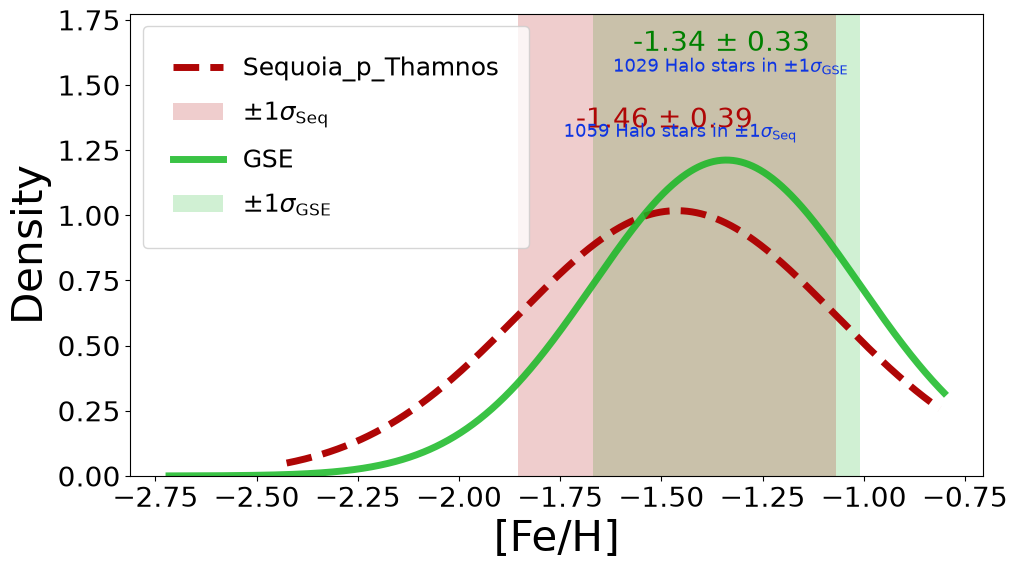

In [127]:
plt.figure(figsize=(11, 6)) #(length, height)
elm_ratio = 'fe_h'
n_components = 1
shift_right = 0.32
fontsize = 20

elm_lable = elm_ratio
elm_lable_display = '/'.join([seg.capitalize() for seg in elm_lable.replace('_', '/').split('/')])

# df = galah_Gaia_Sequoia
# df_mean = np.mean(df[elm_ratio])
# one_sig_df = np.std(df[elm_ratio])
# pl_1sig_df = df_mean + one_sig_df
# min_1sig_df = df_mean - one_sig_df
# plot_gmm(df[elm_ratio].dropna(), f'Sequoia', n_components = n_components, color=Sequoia_C, maximum_peak=True, plot_compents = True, fontsize = fontsize, 
#         #  shift_right=shift_right, shift_up= 0.91)
#         shift_right=-0.25, shift_up= 0.2, linewidth_main = 5)
# plt.axvspan(min_1sig_df, pl_1sig_df, facecolor=Sequoia_C, alpha=0.2, label = r"$\pm 1\sigma_{\mathrm{Seq}}$")

# galah_Gaia_Halo_df_1sig = ((galah_Gaia_Halo[elm_ratio] < pl_1sig_df) & (galah_Gaia_Halo[elm_ratio] > min_1sig_df))
# plt.text(df_mean -0.28, 1.28, f'{len(galah_Gaia_Halo[galah_Gaia_Halo_df_1sig])} Halo stars in 'r"$\pm 1 \sigma_{\mathrm{Seq}}$", c = Halo_C, fontsize = 13.0)
#######################################

df = galah_Gaia_Sequoia_p_thamnos
df_mean = np.mean(df[elm_ratio])
one_sig_df = np.std(df[elm_ratio])
pl_1sig_df = df_mean + one_sig_df
min_1sig_df = df_mean - one_sig_df
plot_gmm(df[elm_ratio].dropna(), f'Sequoia_p_Thamnos', n_components = n_components, color=Sequoia_C, maximum_peak=True, plot_compents = True, fontsize = fontsize, 
        #  shift_right=shift_right, shift_up= 0.91)
        shift_right=-0.25, shift_up= 0.3, linewidth_main = 5, linestyle = '--')
plt.axvspan(min_1sig_df, pl_1sig_df, facecolor=Sequoia_C, alpha=0.2, label = r"$\pm 1\sigma_{\mathrm{Seq}}$")

galah_Gaia_Halo_df_1sig = ((galah_Gaia_Halo[elm_ratio] < pl_1sig_df) & (galah_Gaia_Halo[elm_ratio] > min_1sig_df))
plt.text(df_mean -0.28, 1.3, f'{len(galah_Gaia_Halo[galah_Gaia_Halo_df_1sig])} Halo stars in 'r"$\pm 1 \sigma_{\mathrm{Seq}}$", c = Halo_C, fontsize = 13.0)

##############################################################
gse_mean = np.mean(galah_Gaia_GSE[elm_ratio])
one_sig_gse = np.std(galah_Gaia_GSE[elm_ratio])
pl_1sig_gse = gse_mean + one_sig_gse
min_1sig_gse = gse_mean - one_sig_gse
plot_gmm(galah_Gaia_GSE[elm_ratio].dropna(), f'GSE', n_components = n_components, color=GSE_C, maximum_peak=True, fontsize = fontsize, 
        #  shift_right=shift_right, shift_up= 0.81)
        shift_right=-0.23, shift_up= 0.4, linewidth_main = 5)
plt.axvspan(min_1sig_gse, pl_1sig_gse, facecolor=GSE_C, alpha=0.2, label = r"$\pm 1\sigma_{\mathrm{GSE}}$", zorder=0,)

galah_Gaia_Halo_gse_1sig = ((galah_Gaia_Halo[elm_ratio] < pl_1sig_gse) & (galah_Gaia_Halo[elm_ratio] > min_1sig_gse))
plt.text(gse_mean -0.28, 1.55, f'{len(galah_Gaia_Halo[galah_Gaia_Halo_gse_1sig])} Halo stars in 'r"$\pm 1\sigma_{\mathrm{GSE}}$", c = Halo_C, fontsize = 13.0)


# plot_gmm(galah_Gaia_Halo[elm_ratio].dropna(), f'Halo', n_components = n_components, color='blue', maximum_peak=True, fontsize = fontsize, shift_right=shift_right, shift_up= 0.71)

# plt.hist(galah_Gaia_Sequoia[elm_ratio].dropna(), bins=30, color = 'r', alpha=0.5, label='Sequoia', density=True, histtype='step')
# plt.hist(galah_Gaia_GSE[elm_ratio].dropna(), bins=30, color = 'g', density=True, histtype='step')
# plt.hist(galah_Gaia_Halo[elm_ratio].dropna(), bins=30, color = Halo_C, alpha=0.5, label='Halo', density=True, histtype='step', linewidth = 5)

# galah_Kushniruk_Thamnos1_mask = (galah_Kushniruk_Thamnos1['fe_h'] <-0.75)
# plt.hist(galah_Kushniruk_Thamnos1[galah_Kushniruk_Thamnos1_mask][elm_ratio].dropna(), bins=30, color = 'darkseagreen', alpha=0.5, label='Thamnos', density=True, histtype='step')
# plot_gmm(galah_Kushniruk_Thamnos1[galah_Kushniruk_Thamnos1_mask][elm_ratio].dropna(), f'Halo', n_components = 3, color='darkseagreen', maximum_peak=True, fontsize = fontsize, shift_right=shift_right, shift_up= 0.61)

leg = plt.legend(fontsize=18, labelspacing=0.8, borderpad=1.2, loc = 'upper left')
# for handle in leg.legend_handles:
    # handle.set_sizes([100])

peak_height  = max(plt.gca().get_ylim())
plt.ylim(0, peak_height + 0.5)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
plt.xlabel(f'[{elm_lable_display}]', fontsize = 30)
plt.ylabel('Density', fontsize = 30)


# plt.savefig('Sec and GSE metalicity.png', dpi = 2400, bbox_inches='tight')


In [101]:

element_list_partial_small_galah_7 = [ 'fe', 'cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_2 = ['cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_3 = ['fe', 'v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']
element_list_partial_small_galah_7_4 = ['fe', 'si', 'nd', 'na', 'mg', 'k', 'ca', 'sc', 'ti', 'v', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba']
element_list_partial_small_galah_7_5 = [ 'v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']  # now I wonder if I could use sm_fe, o_fe, 
element_list_partial_small_galah_10 = ['fe', 'v', 'sc', 'si', 'ca', 'mn', 'na', 'nd']                                                             # and/or la_fe
element_list_partial_small_galah_11 = ['y', 'ba', 'nd', 'eu']                                                                                 # also la and sm would bring me to (50, 45, or 44combined)/65 sequoia stars otherwise
element_list_partial_small_galah_16 =  ["na", "mg", "ca", "ti", "cr" ,"mn", "ni", 'cu', 'y', "ba", "nd"] #This is what I used in my Poster
element_list_partial_small_galah_17 =  ['fe', "na", "mg", "ca", "ti", "cr" ,"mn", "ni", 'cu', 'y', "ba", "nd"]
element_list_partial_small_galah_18 =  ['fe', "na", "mg", 'si', "ca", "ti", "mn", "ni", 'cu', 'y', "ba", "nd"]


ASA_Plots_ratios = ['fe', 'si', 'ca', 'ti', 'mn', 'ni', 'y', 'nd']
S_VS_G_best_elms = ['na', 'mn', 'ti', 'cr']

# element_list = S_VS_G_best_elms
element_list = element_list_partial_small_galah_18


galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia, element_list)

galah_Gaia_new_ratios = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0] # this ontains a full catalog from galah but now it includes ratios for Ca, Si, Ti, Ni, Zr, Ce, and Nd relative to eachother: Pradosh did recomend taking out
                                                                 # Si, and Ni whitch I can do by changing "element_list_partial_large" to element_list_partial_small
galah_gaia_new_element_ratio_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[1]     # this just lists the new columns ratios so I can more easily call them
galah_gaia_new_element_ratio_errors_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[2] 

galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_GSE, element_list)
galah_Gaia_GSE_new_ratios = galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_GSE, element_list)
galah_Gaia_Kushniruk_GSE_new_ratios = galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Sequoia, element_list)
galah_Gaia_Sequoia_new_ratios = galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Sequoia_p_Thamnos_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Sequoia_p_thamnos, element_list)
galah_Gaia_Sequoia_p_Thamnos_new_ratios = galah_Gaia_Sequoia_p_Thamnos_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC3201_galah, element_list)
# galah_Gaia_NGC3201_new_ratios = galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC5139_galah, element_list)
galah_Gaia_NGC5139_new_ratios = galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos1, element_list)
galah_Gaia_Thamnos1_new_ratios = galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos2, element_list)
galah_Gaia_Thamnos2_new_ratios = galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC1851_galah, element_list)
# galah_Gaia_NGC1851_new_ratios = galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Halo, element_list)
galah_Gaia_Halo_new_ratios = galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist[0]

Halo_Pradosh_galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(Halo_Pradosh_galah_Gaia, element_list)
Halo_Pradosh_galah_Gaia_new_ratios = Halo_Pradosh_galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_else_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_else, element_list)
galah_Gaia_else_new_ratios = galah_Gaia_else_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_raw_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_raw, element_list)
galah_Gaia_raw_new_ratios = galah_Gaia_raw_new_ratios_catolog_ratiolist_ratioerrorlist[0]


'----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------'

# element_list_full_galah_almost = ["n", "o", "na", "mg", "al", "si", "k", "ca", "sc" ,"ti", "v", "cr" ,"mn", "co", "ni", "cu", "zn", "y", "zr", "ba", "la", "ce", "nd", "sm", "eu"]# there is nn_li in galah (nural network Li/Fe) but I dont want to include that right now.
element_list_full_galah_almost = ['fe', 'c', 'n', "o", "na", "mg", "al", "si", "k", "ca", "sc" ,"ti", "v", "cr" ,"mn", "co", "ni", "cu", "zn", 
                                  'rb', 'sr', 
                                  "y", "zr", 
                                  'mo', 'ru',
                                  "ba", "la", "ce", "nd", "sm", "eu"]# there is nn_li in galah (nural network Li/Fe) but I dont want to include that right now.


element_list_nessessary_flags = element_list_full_galah_almost

galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(galah_Gaia, element_list_nessessary_flags)
galah_Gaia_new_ratios_nessessary_flags_ratio_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[1]
galah_Gaia_new_ratios_nessessary_flags = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0]


galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(galah_Gaia_Sequoia, element_list_nessessary_flags)
galah_Gaia_Sequoia_new_ratios_nessessary_flags = galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist[0]
 
galah_Gaia_Sequoia_p_Thamnos_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(galah_Gaia_Sequoia_p_thamnos, element_list)
galah_Gaia_Sequoia_p_Thamnos_new_ratios_nessessary_flags = galah_Gaia_Sequoia_p_Thamnos_new_ratios_catolog_ratiolist_ratioerrorlist[0]


galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(galah_Gaia_GSE, element_list_nessessary_flags)
galah_Gaia_GSE_new_ratios_nessessary_flags = galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Thamnos_1_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(galah_Kushniruk_Thamnos1, element_list_nessessary_flags)
galah_Gaia_Thamnos_1_new_ratios_nessessary_flags = galah_Gaia_Thamnos_1_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Thamnos_2_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(galah_Kushniruk_Thamnos2, element_list_nessessary_flags)
galah_Gaia_Thamnos_2_new_ratios_nessessary_flags = galah_Gaia_Thamnos_2_new_ratios_catolog_ratiolist_ratioerrorlist[0]


galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(galah_Gaia_Halo, element_list_nessessary_flags)
galah_Gaia_Halo_new_ratios_nessessary_flags = galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist[0]

Halo_Pradosh_galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(Halo_Pradosh_galah_Gaia, element_list_nessessary_flags)
Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags = Halo_Pradosh_galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0]



/Users/simoncorrera/Desktop/MQ NGC3201 project copy/Jupyter Notebooks/equations_file.py:909: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_set_flagged[new_ratio_label] = data_set_flagged[col_name_for_numerator] - data_set_flagged[col_name_for_denominator] # this adds a new column to galah's catalog. It give the column the name and finds the ratio values

/Users/simoncorrera/Desktop/MQ NGC3201 project copy/Jupyter Notebooks/equations_file.py:908: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  

/Users/simoncorrera/Desktop/MQ 

In [102]:
galah_Gaia_Sequoia_new_ratios_nessessary_flags['cu_h'] = galah_Gaia_Sequoia_new_ratios_nessessary_flags['cu_fe'] + galah_Gaia_Sequoia_new_ratios_nessessary_flags['fe_h']
Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags['cu_h'] = Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags['cu_fe'] + Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags['fe_h']
galah_Gaia_GSE_new_ratios_nessessary_flags['cu_h'] = galah_Gaia_GSE_new_ratios_nessessary_flags['cu_fe'] + galah_Gaia_GSE_new_ratios_nessessary_flags['fe_h']
galah_Gaia_Sequoia_p_Thamnos_new_ratios_nessessary_flags['cu_h'] = galah_Gaia_Sequoia_p_Thamnos_new_ratios_nessessary_flags['cu_fe'] + galah_Gaia_Sequoia_p_Thamnos_new_ratios_nessessary_flags['fe_h']

/var/folders/k3/63pgq9cd0rvg7fhy2d0q_sj40000gp/T/ipykernel_34894/1166439328.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  galah_Gaia_Sequoia_new_ratios_nessessary_flags['cu_h'] = galah_Gaia_Sequoia_new_ratios_nessessary_flags['cu_fe'] + galah_Gaia_Sequoia_new_ratios_nessessary_flags['fe_h']

/var/folders/k3/63pgq9cd0rvg7fhy2d0q_sj40000gp/T/ipykernel_34894/1166439328.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags['cu_h'] = Halo_Pradosh_galah_Gaia_new_ratios_nessessary

In [103]:
galah_Gaia_Sequoia_p_Thamnos_new_ratios_nessessary_flags['cu_h']

48563          NaN
52359    -1.470451
61019          NaN
187014   -1.355221
193867   -1.508853
            ...   
897902         NaN
901929   -1.320243
902327         NaN
908513         NaN
911972   -1.203073
Name: cu_h, Length: 92, dtype: float64

-2.7691708
Halo: mean = -1.3517066879552888
GSE: mean = -1.3394100605687203
Seq_con: mean = -1.598094440873016
Seq_Tham: mean = -1.2476426052631577
Tham2: mean = -1.6840873210526315


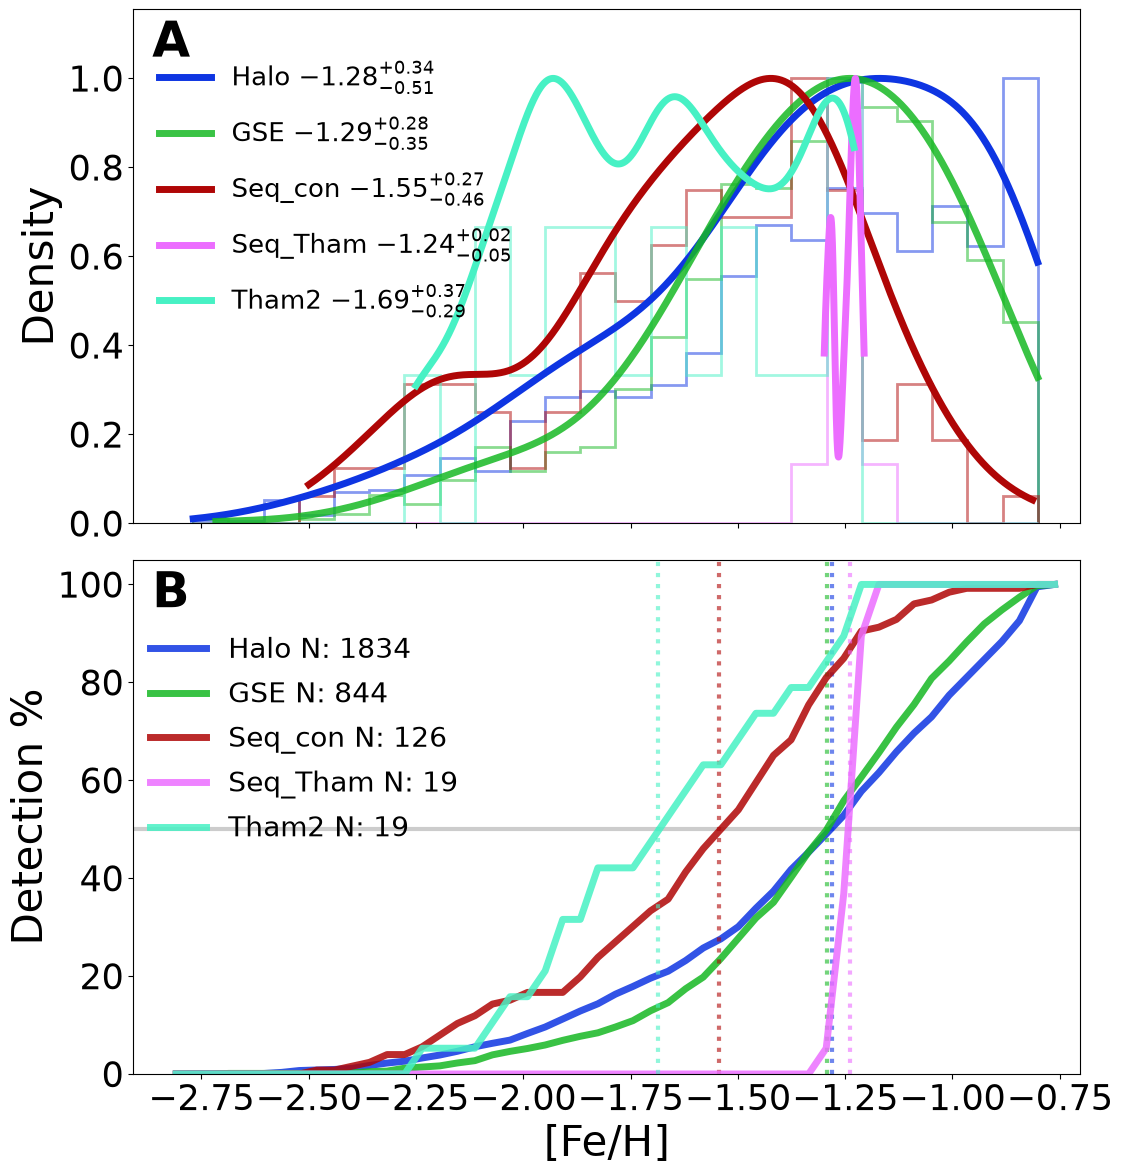

In [ ]:
num_bins = 50
percentiles = [16, 50, 84]

elm_ratios = ['fe_h']

# Datasets mapping: name -> (dataframe_with_columns, color)
# datasets = {
#     'Seq': (galah_Gaia_Sequoia_new_ratios, Sequoia_C, 'solid'),
#     # 'Seq_p_Tham': (galah_Gaia_Sequoia_p_Thamnos_new_ratios, Sequoia_C, '--'),
#     'GSE': (galah_Gaia_GSE_new_ratios, GSE_C, 'solid'),
#     'Halo': (Halo_Pradosh_galah_Gaia_new_ratios, Halo_C, 'solid'),
#     # 'Tham1': (galah_Gaia_Thamnos_1_new_ratios, thamnos_1_C, 'solid'),
#     # 'Tham2': (galah_Gaia_Thamnos_2_new_ratios, thamnos_2_C, 'solid'),
# }

datasets = {
    'Halo': (Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags, Halo_C, 'solid', ':'), #df, color, main_ls, 50%_ls
    'GSE': (galah_Gaia_GSE_new_ratios_nessessary_flags, GSE_C, 'solid', ':'),
    'Seq_con': (galah_Gaia_Sequoia_new_ratios_nessessary_flags, Sequoia_C, 'solid', ':'),
    'Seq_Tham': (galah_Gaia_Sequoia_p_Thamnos_new_ratios_nessessary_flags, Sequoia_C_2, 'solid', ':'),
    # 'Tham1': (galah_Gaia_Thamnos_1_new_ratios_nessessary_flags, thamnos_1_C, 'solid', ':'),
    'Tham2': (galah_Gaia_Thamnos_2_new_ratios_nessessary_flags, thamnos_2_C, 'solid', ':'),
}

# Reference dataset to set the edges/range (use 'Halo' as default)
ref = next(iter(datasets))

for elm_ratio in elm_ratios:
    elm_lable = 'cu_h'
    data, results, edges, min_value, max_value = kde_and_percentiles(datasets, ref, elm_ratio, num_bins = 50, percentiles = [16, 50, 84])


    fig, ax = plt.subplots(2, 1, sharex=True, sharey=False, figsize=(11, 12)) # (rows, colums, share y axis and/or share x axis)
    fontsize = 30
    labelsize = 25

    elm_ratio = elm_ratio
    elm_lable = elm_ratio
    elm_lable_display = '/'.join([seg.capitalize() for seg in elm_lable.replace('_', '/').split('/')])

    n_components = 1
    shift_right = 0.32
    'Gausian Curve for Sequoia'


    # sec_mean = np.mean(galah_Gaia_Sequoia[elm_ratio])
    # one_sig_sec = np.std(galah_Gaia_Sequoia[elm_ratio])
    # pl_1sig_sec = sec_mean + one_sig_sec
    # min_1sig_sec = sec_mean - one_sig_sec
    # plot_gmm(galah_Gaia_Sequoia[elm_ratio].dropna(), f'Sequoia', n_components = n_components, color=Sequoia_C, maximum_peak=True, plot_compents = True, fontsize = fontsize, 
    #         #  shift_right=shift_right, shift_up= 0.91)
    #         shift_right=-0.25, shift_up= 0.2, linewidth_main = 5,
    #         ax = ax[0])
    # ax[0].axvspan(min_1sig_sec, pl_1sig_sec, facecolor=Sequoia_C, alpha=0.2, label = r"$\pm 1\sigma_{\mathrm{Sec}}$")

    # galah_Gaia_Halo_sec_1sig = ((galah_Gaia_Halo[elm_ratio] < pl_1sig_sec) & (galah_Gaia_Halo[elm_ratio] > min_1sig_sec))
    # ax[0].text(sec_mean -0.28, 1.28, f'{len(galah_Gaia_Halo[galah_Gaia_Halo_sec_1sig])} Halo stars in 'r"$\pm 1 \sigma_{\mathrm{Sec}}$", c = Halo_C, fontsize = 13.0)


    'Gausian Curve for GSE'
    # gse_mean = np.mean(galah_Gaia_GSE[elm_ratio])
    # one_sig_gse = np.std(galah_Gaia_GSE[elm_ratio])
    # pl_1sig_gse = gse_mean + one_sig_gse
    # min_1sig_gse = gse_mean - one_sig_gse
    # plot_gmm(galah_Gaia_GSE[elm_ratio].dropna(), f'GSE', n_components = n_components, color=GSE_C, maximum_peak=True, fontsize = fontsize, 
    #         #  shift_right=shift_right, shift_up= 0.81)
    #         shift_right=-0.23, shift_up= 0.4, linewidth_main = 5,
    #         ax = ax[0])
    # ax[0].axvspan(min_1sig_gse, pl_1sig_gse, facecolor=GSE_C, alpha=0.2, label = r"$\pm 1\sigma_{\mathrm{GSE}}$", zorder=0,)

    # galah_Gaia_Halo_gse_1sig = ((galah_Gaia_Halo[elm_ratio] < pl_1sig_gse) & (galah_Gaia_Halo[elm_ratio] > min_1sig_gse))
    # ax[0].text(gse_mean -0.28, 1.55, f'{len(galah_Gaia_Halo[galah_Gaia_Halo_gse_1sig])} Halo stars in 'r"$\pm 1\sigma_{\mathrm{GSE}}$", c = Halo_C, fontsize = 13.0)


    'Gausian Curve for Halo'
    # plot_gmm(galah_Gaia_Halo[elm_ratio].dropna(), f'Halo', n_components = n_components, color='blue', maximum_peak=True, fontsize = fontsize, shift_right=shift_right, shift_up= 0.71)

    ####################################################################
    'Histograms'

    for name, (d, c, ls, ls_2, label, percentiles_label) in data.items():
        # compute shared bin edges from all samples (uses 30 bins)
        all_vals = np.concatenate([t[0].dropna().values for t in data.values()])
        shared_bins = np.linspace(np.nanmin(all_vals), np.nanmax(all_vals), 25)

        counts, bins = np.histogram(d.dropna().values, bins=shared_bins)
        # Normalise so the highest bin = 1
        counts = counts / counts.max() if counts.size and counts.max() > 0 else counts

        ax[0].stairs(
            counts,
            bins,
            color=c,
            ls = ls,
            # label=label,
            linewidth=2,
            alpha = 0.5
        )

    #####################################################################
    'Kernal Density estimates'

    for name, (d, c, ls, ls_2, label, percentiles_label) in data.items():
        x = d.dropna().values
        mean_x = np.mean(x)
        print(f'{name}: mean = {mean_x}')

        # sklearn expects shape (n_samples, n_features)
        x_2d = x.reshape(-1, 1)

        bandwidth_percent = 0.075
        bandwidth_range = np.ptp(x)  # full observed range of the sample
        bandwidth = max(bandwidth_range * bandwidth_percent, 1e-6)
        # print(bandwidth)
        kde = KernelDensity(
            kernel='gaussian',
            bandwidth=bandwidth
        )
        
        kde.fit(x_2d)

        x_grid = np.linspace(x.min(), x.max(), 1000).reshape(-1, 1)

        density = np.exp(kde.score_samples(x_grid))
        # normalize so the peak density for this sample is 1
        max_density = density.max() if density.size else 0.0
        if max_density > 0:
            density = density / max_density

        ax[0].plot(
            x_grid[:, 0],
            density,
            color=c,
            ls = ls,
            linewidth=5,
            label= label
        )
        
    ######################################################################
    'labels'
    ax[0].text(0.02, 0.98, 'A', transform=ax[0].transAxes, fontsize=fontsize+5, fontweight='bold', va='top', ha='left')
    leg = ax[0].legend(fontsize=fontsize/1.6, labelspacing=0.8, borderpad=1.2, frameon=False, loc='center left',
                    bbox_to_anchor=(-0.02, 0.65)
                    )
    # for handle in leg.legend_handles:
        # handle.set_sizes([100])

    peak_height  = max(ax[0].get_ylim())
    ax[0].set_ylim(0, peak_height * 1.1)
    ax[0].tick_params(axis='x', labelsize=labelsize)
    ax[0].tick_params(axis='y', labelsize=labelsize)
    # ax[0].set_xlim(min_value,max_value)


    ax[0].set_ylabel('Density', fontsize = fontsize)

    #########################################################################################

    linewidth = 5
    ax[1].axhline(50, linestyle='solid', linewidth=3, alpha=0.4, c='grey')
    # ax[1].axhline(16, linestyle='solid', linewidth=3, alpha=0.4, c='grey')
    # ax[1].axhline(84, linestyle='solid', linewidth=3, alpha=0.4, c='grey')
    
    #############################################
    x_min_candidates = []
    x_max_candidates = []

    lower_percent = 1
    upper_percent = 99

    for name, info in results.items():
        perc = info.get('percents')

        if perc is None or edges is None:
            continue

        perc = np.asarray(perc)
        edges_arr = np.asarray(edges)

        # Find x where cumulative detection is closest to
        # the chosen lower and upper percentages
        valid = np.isfinite(perc) & np.isfinite(edges_arr)

        if not np.any(valid):
            continue

        x_valid = edges_arr[valid]
        p_valid = perc[valid]

        x_lower = x_valid[np.argmin(np.abs(p_valid - lower_percent))]
        x_upper = x_valid[np.argmin(np.abs(p_valid - upper_percent))]

        x_min_candidates.append(x_lower)
        x_max_candidates.append(x_upper)

    # Combine all datasets
    if x_min_candidates and x_max_candidates:
        xmin = min(x_min_candidates)
        xmax = max(x_max_candidates)

        # Add a little padding
        padding = 0.05 * (xmax - xmin)

        ax[1].set_xlim(xmin - padding, xmax + padding)
        ax[0].set_xlim(xmin - padding, xmax + padding)
        
    ##################################################
    # Plot cumulative percent curves from results
    for name, info in results.items():
        pts = info.get('points', {})
        perc = info.get('percents')
        total = info.get('total', 0)
        color = info.get('color', '#000000')
        ls = info.get('ls')
        ls_2 = info.get('ls_2')
        if perc is not None and edges is not None:
            ax[1].plot(edges, perc, color=color, ls = ls, linewidth=linewidth, label=f"{name} N: {total}", alpha=0.85)

        # Vertical lines for percentiles per dataset
        linestyles = {50: ls_2, 
                    #   16: '-.', 
                    #   84: ':'
                    }
        for p, ls_percent in linestyles.items():
            val = pts.get(p, np.nan)
            if not np.isnan(val):
                ax[1].axvline(val, color=color, linestyle=ls_percent, linewidth=3, alpha=0.6)

    # Labels, ticks, legend
    elm_lable = elm_ratio
    elm_lable_display = '/'.join([seg.capitalize() for seg in elm_lable.replace('_', '/').split('/')])
    ax[1].set_xlabel(f'[{elm_lable_display}]', fontsize = fontsize)
    ax[1].set_ylabel('Detection %', fontsize = fontsize)
    ax[1].tick_params(axis='x', labelsize=labelsize)
    ax[1].tick_params(axis='y', labelsize=labelsize)
    ax[1].text(0.02, 0.98, 'B', transform=ax[1].transAxes, fontsize=fontsize+5, fontweight='bold', va='top', ha='left')
    leg = ax[1].legend(fontsize=fontsize/1.5, labelspacing=0.6, borderpad=0.8, frameon=False, loc='center left',
                       bbox_to_anchor=(-0.02, 0.65),
                       )
    ax[1].set_ylim(0,105)
    # ax[1].set_xlim(min_value, max_value)

    # ax[0].axvline(-1.2, color=color, linestyle=ls, linewidth=3, alpha=0.6)
    # ax[0].axvline(-1.3, color=color, linestyle=ls, linewidth=3, alpha=0.6)

    plt.tight_layout()


-2.5819
Halo: mean = -1.2123862157165606
GSE: mean = -1.247149654129264
Seq_con: mean = -1.4476062231884057
Seq_Tham: mean = -1.256220259245283


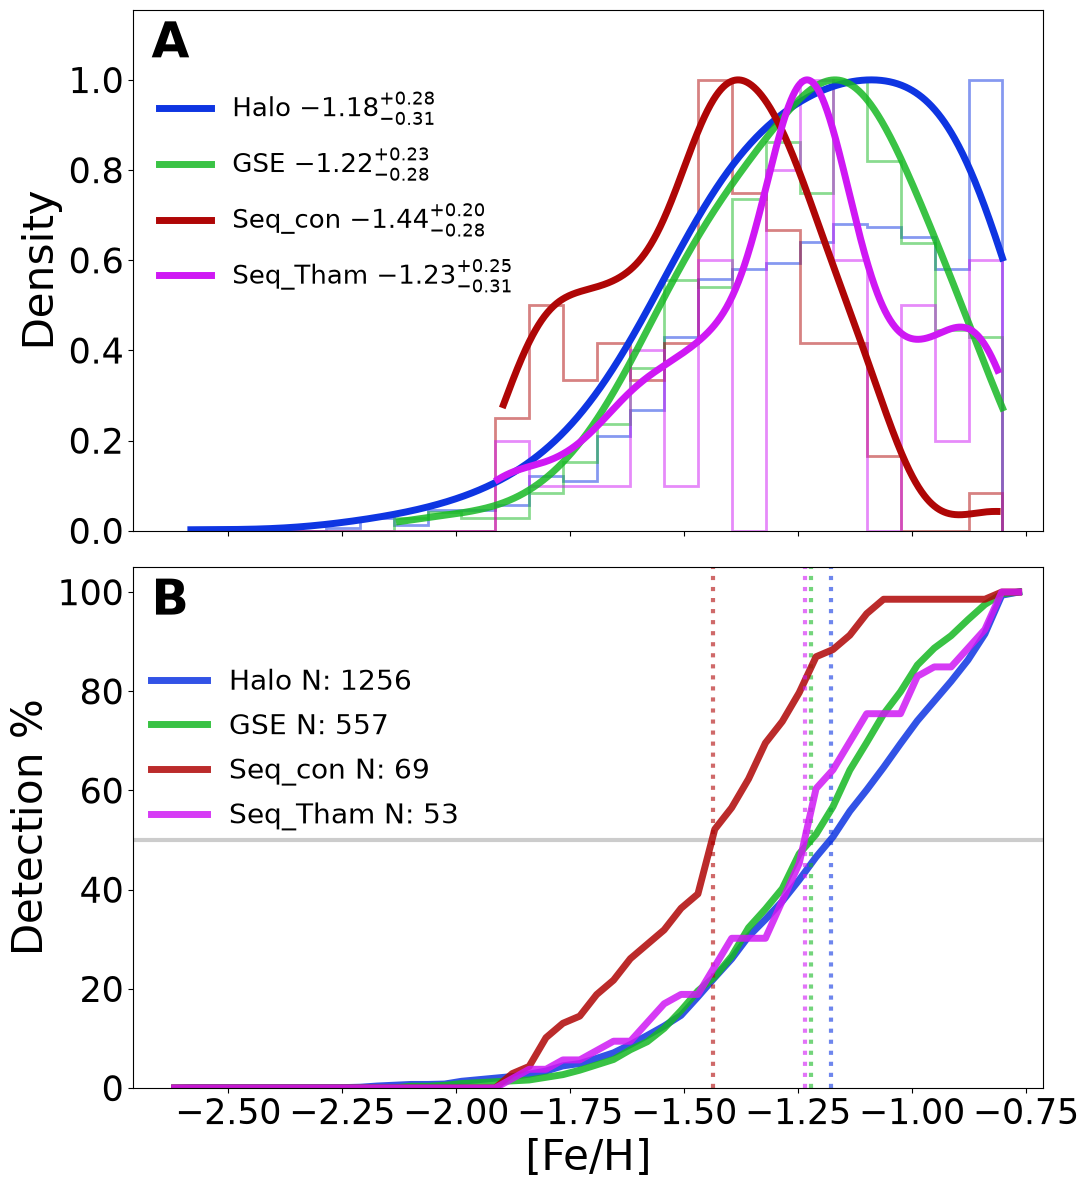

In [113]:
num_bins = 50
percentiles = [16, 50, 84]

elm_ratios = ['fe_h']

# Datasets mapping: name -> (dataframe_with_columns, color)
datasets = {
    'Halo': (Halo_Pradosh_galah_Gaia_new_ratios, Halo_C, 'solid', ':'),
    'GSE': (galah_Gaia_GSE_new_ratios, GSE_C, 'solid', ':'),
    'Seq_con': (galah_Gaia_Sequoia_new_ratios, Sequoia_C, 'solid', ':'),
    'Seq_Tham': (galah_Gaia_Sequoia_p_Thamnos_new_ratios, Sequoia_C_2, 'solid', ':'),
    # 'Tham1': (galah_Gaia_Thamnos_1_new_ratios, thamnos_1_C, 'solid', ':'),
    # 'Tham2': (galah_Gaia_Thamnos_2_new_ratios, thamnos_2_C, 'solid', ':'),
}

# datasets = {
#     'Halo': (Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags, Halo_C, 'solid', ':'), #df, color, main_ls, 50%_ls
#     'GSE': (galah_Gaia_GSE_new_ratios_nessessary_flags, GSE_C, 'solid', ':'),
#     'Seq_con': (galah_Gaia_Sequoia_new_ratios_nessessary_flags, Sequoia_C, 'solid', ':'),
#     'Seq_Tham': (galah_Gaia_Sequoia_p_Thamnos_new_ratios_nessessary_flags, Sequoia_C_2, 'solid', ':'),
#     # 'Tham1': (galah_Gaia_Thamnos_1_new_ratios_nessessary_flags, thamnos_1_C, 'solid', ':'),
#     # 'Tham2': (galah_Gaia_Thamnos_2_new_ratios_nessessary_flags, thamnos_2_C, 'solid', ':'),
# }

# Reference dataset to set the edges/range (use 'Halo' as default)
ref = next(iter(datasets))
for elm_ratio in elm_ratios:
    data, results, edges, min_value, max_value = kde_and_percentiles(datasets, ref, elm_ratio, num_bins = 50, percentiles = [16, 50, 84])


    fig, ax = plt.subplots(2, 1, sharex=True, sharey=False, figsize=(11, 12)) # (rows, colums, share y axis and/or share x axis)
    fontsize = 30
    labelsize = 25

    elm_ratio = elm_ratio
    elm_lable = elm_ratio
    elm_lable_display = '/'.join([seg.capitalize() for seg in elm_lable.replace('_', '/').split('/')])

    n_components = 1
    shift_right = 0.32
    'Gausian Curve for Sequoia'


    # sec_mean = np.mean(galah_Gaia_Sequoia[elm_ratio])
    # one_sig_sec = np.std(galah_Gaia_Sequoia[elm_ratio])
    # pl_1sig_sec = sec_mean + one_sig_sec
    # min_1sig_sec = sec_mean - one_sig_sec
    # plot_gmm(galah_Gaia_Sequoia[elm_ratio].dropna(), f'Sequoia', n_components = n_components, color=Sequoia_C, maximum_peak=True, plot_compents = True, fontsize = fontsize, 
    #         #  shift_right=shift_right, shift_up= 0.91)
    #         shift_right=-0.25, shift_up= 0.2, linewidth_main = 5,
    #         ax = ax[0])
    # ax[0].axvspan(min_1sig_sec, pl_1sig_sec, facecolor=Sequoia_C, alpha=0.2, label = r"$\pm 1\sigma_{\mathrm{Sec}}$")

    # galah_Gaia_Halo_sec_1sig = ((galah_Gaia_Halo[elm_ratio] < pl_1sig_sec) & (galah_Gaia_Halo[elm_ratio] > min_1sig_sec))
    # ax[0].text(sec_mean -0.28, 1.28, f'{len(galah_Gaia_Halo[galah_Gaia_Halo_sec_1sig])} Halo stars in 'r"$\pm 1 \sigma_{\mathrm{Sec}}$", c = Halo_C, fontsize = 13.0)


    'Gausian Curve for GSE'
    # gse_mean = np.mean(galah_Gaia_GSE[elm_ratio])
    # one_sig_gse = np.std(galah_Gaia_GSE[elm_ratio])
    # pl_1sig_gse = gse_mean + one_sig_gse
    # min_1sig_gse = gse_mean - one_sig_gse
    # plot_gmm(galah_Gaia_GSE[elm_ratio].dropna(), f'GSE', n_components = n_components, color=GSE_C, maximum_peak=True, fontsize = fontsize, 
    #         #  shift_right=shift_right, shift_up= 0.81)
    #         shift_right=-0.23, shift_up= 0.4, linewidth_main = 5,
    #         ax = ax[0])
    # ax[0].axvspan(min_1sig_gse, pl_1sig_gse, facecolor=GSE_C, alpha=0.2, label = r"$\pm 1\sigma_{\mathrm{GSE}}$", zorder=0,)

    # galah_Gaia_Halo_gse_1sig = ((galah_Gaia_Halo[elm_ratio] < pl_1sig_gse) & (galah_Gaia_Halo[elm_ratio] > min_1sig_gse))
    # ax[0].text(gse_mean -0.28, 1.55, f'{len(galah_Gaia_Halo[galah_Gaia_Halo_gse_1sig])} Halo stars in 'r"$\pm 1\sigma_{\mathrm{GSE}}$", c = Halo_C, fontsize = 13.0)


    'Gausian Curve for Halo'
    # plot_gmm(galah_Gaia_Halo[elm_ratio].dropna(), f'Halo', n_components = n_components, color='blue', maximum_peak=True, fontsize = fontsize, shift_right=shift_right, shift_up= 0.71)

    ####################################################################
    'Histograms'

    for name, (d, c, ls, ls_2, label, percentiles_label) in data.items():
        # compute shared bin edges from all samples (uses 30 bins)
        all_vals = np.concatenate([t[0].dropna().values for t in data.values()])
        shared_bins = np.linspace(np.nanmin(all_vals), np.nanmax(all_vals), 25)

        counts, bins = np.histogram(d.dropna().values, bins=shared_bins)
        # Normalise so the highest bin = 1
        counts = counts / counts.max() if counts.size and counts.max() > 0 else counts

        ax[0].stairs(
            counts,
            bins,
            color=c,
            ls = ls,
            # label=label,
            linewidth=2,
            alpha = 0.5
        )

    #####################################################################
    'Kernal Density estimates'

    for name, (d, c, ls, ls_2, label, percentiles_label) in data.items():
        x = d.dropna().values
        mean_x = np.mean(x)
        print(f'{name}: mean = {mean_x}')

        # sklearn expects shape (n_samples, n_features)
        x_2d = x.reshape(-1, 1)

        bandwidth_percent = 0.075
        bandwidth_range = np.ptp(x)  # full observed range of the sample
        bandwidth = max(bandwidth_range * bandwidth_percent, 1e-6)
        # print(bandwidth)
        kde = KernelDensity(
            kernel='gaussian',
            bandwidth=bandwidth
        )
        
        kde.fit(x_2d)

        x_grid = np.linspace(x.min(), x.max(), 1000).reshape(-1, 1)

        density = np.exp(kde.score_samples(x_grid))
        # normalize so the peak density for this sample is 1
        max_density = density.max() if density.size else 0.0
        if max_density > 0:
            density = density / max_density

        ax[0].plot(
            x_grid[:, 0],
            density,
            color=c,
            ls = ls,
            linewidth=5,
            label= label
        )
        
    ######################################################################
    'labels'
    ax[0].text(0.02, 0.98, 'A', transform=ax[0].transAxes, fontsize=fontsize+5, fontweight='bold', va='top', ha='left')
    leg = ax[0].legend(fontsize=fontsize/1.6, labelspacing=0.8, borderpad=1.2, frameon=False, loc='center left',
                    bbox_to_anchor=(-0.02, 0.65)
                    )
    # for handle in leg.legend_handles:
        # handle.set_sizes([100])

    peak_height  = max(ax[0].get_ylim())
    ax[0].set_ylim(0, peak_height * 1.1)
    ax[0].tick_params(axis='x', labelsize=labelsize)
    ax[0].tick_params(axis='y', labelsize=labelsize)
    # ax[0].set_xlim(min_value,max_value)


    ax[0].set_ylabel('Density', fontsize = fontsize)

    #########################################################################################

    linewidth = 5
    ax[1].axhline(50, linestyle='solid', linewidth=3, alpha=0.4, c='grey')
    # ax[1].axhline(16, linestyle='solid', linewidth=3, alpha=0.4, c='grey')
    # ax[1].axhline(84, linestyle='solid', linewidth=3, alpha=0.4, c='grey')
    
    #############################################
    x_min_candidates = []
    x_max_candidates = []

    lower_percent = 1
    upper_percent = 99

    for name, info in results.items():
        perc = info.get('percents')

        if perc is None or edges is None:
            continue

        perc = np.asarray(perc)
        edges_arr = np.asarray(edges)

        # Find x where cumulative detection is closest to
        # the chosen lower and upper percentages
        valid = np.isfinite(perc) & np.isfinite(edges_arr)

        if not np.any(valid):
            continue

        x_valid = edges_arr[valid]
        p_valid = perc[valid]

        x_lower = x_valid[np.argmin(np.abs(p_valid - lower_percent))]
        x_upper = x_valid[np.argmin(np.abs(p_valid - upper_percent))]

        x_min_candidates.append(x_lower)
        x_max_candidates.append(x_upper)

    # Combine all datasets
    if x_min_candidates and x_max_candidates:
        xmin = min(x_min_candidates)
        xmax = max(x_max_candidates)

        # Add a little padding
        padding = 0.05 * (xmax - xmin)

        ax[1].set_xlim(xmin - padding, xmax + padding)
        ax[0].set_xlim(xmin - padding, xmax + padding)
        
    ##################################################
    # Plot cumulative percent curves from results
    for name, info in results.items():
        pts = info.get('points', {})
        perc = info.get('percents')
        total = info.get('total', 0)
        color = info.get('color', '#000000')
        ls = info.get('ls')
        ls_2 = info.get('ls_2')
        if perc is not None and edges is not None:
            ax[1].plot(edges, perc, color=color, ls = ls, linewidth=linewidth, label=f"{name} N: {total}", alpha=0.85)

        # Vertical lines for percentiles per dataset
        linestyles = {50: ls_2, 
                    #   16: '-.', 
                    #   84: ':'
                    }
        for p, ls_percent in linestyles.items():
            val = pts.get(p, np.nan)
            if not np.isnan(val):
                ax[1].axvline(val, color=color, linestyle=ls_percent, linewidth=3, alpha=0.6)

    # Labels, ticks, legend
    elm_lable = elm_ratio
    elm_lable_display = '/'.join([seg.capitalize() for seg in elm_lable.replace('_', '/').split('/')])
    ax[1].set_xlabel(f'[{elm_lable_display}]', fontsize = fontsize)
    ax[1].set_ylabel('Detection %', fontsize = fontsize)
    ax[1].tick_params(axis='x', labelsize=labelsize)
    ax[1].tick_params(axis='y', labelsize=labelsize)
    ax[1].text(0.02, 0.98, 'B', transform=ax[1].transAxes, fontsize=fontsize+5, fontweight='bold', va='top', ha='left')
    leg = ax[1].legend(fontsize=fontsize/1.5, labelspacing=0.6, borderpad=0.8, frameon=False, loc='center left',
                       bbox_to_anchor=(-0.02, 0.65),
                       )
    ax[1].set_ylim(0,105)
    # ax[1].set_xlim(min_value, max_value)

    # ax[0].axvline(-1.2, color=color, linestyle=ls, linewidth=3, alpha=0.6)
    plt.tight_layout()


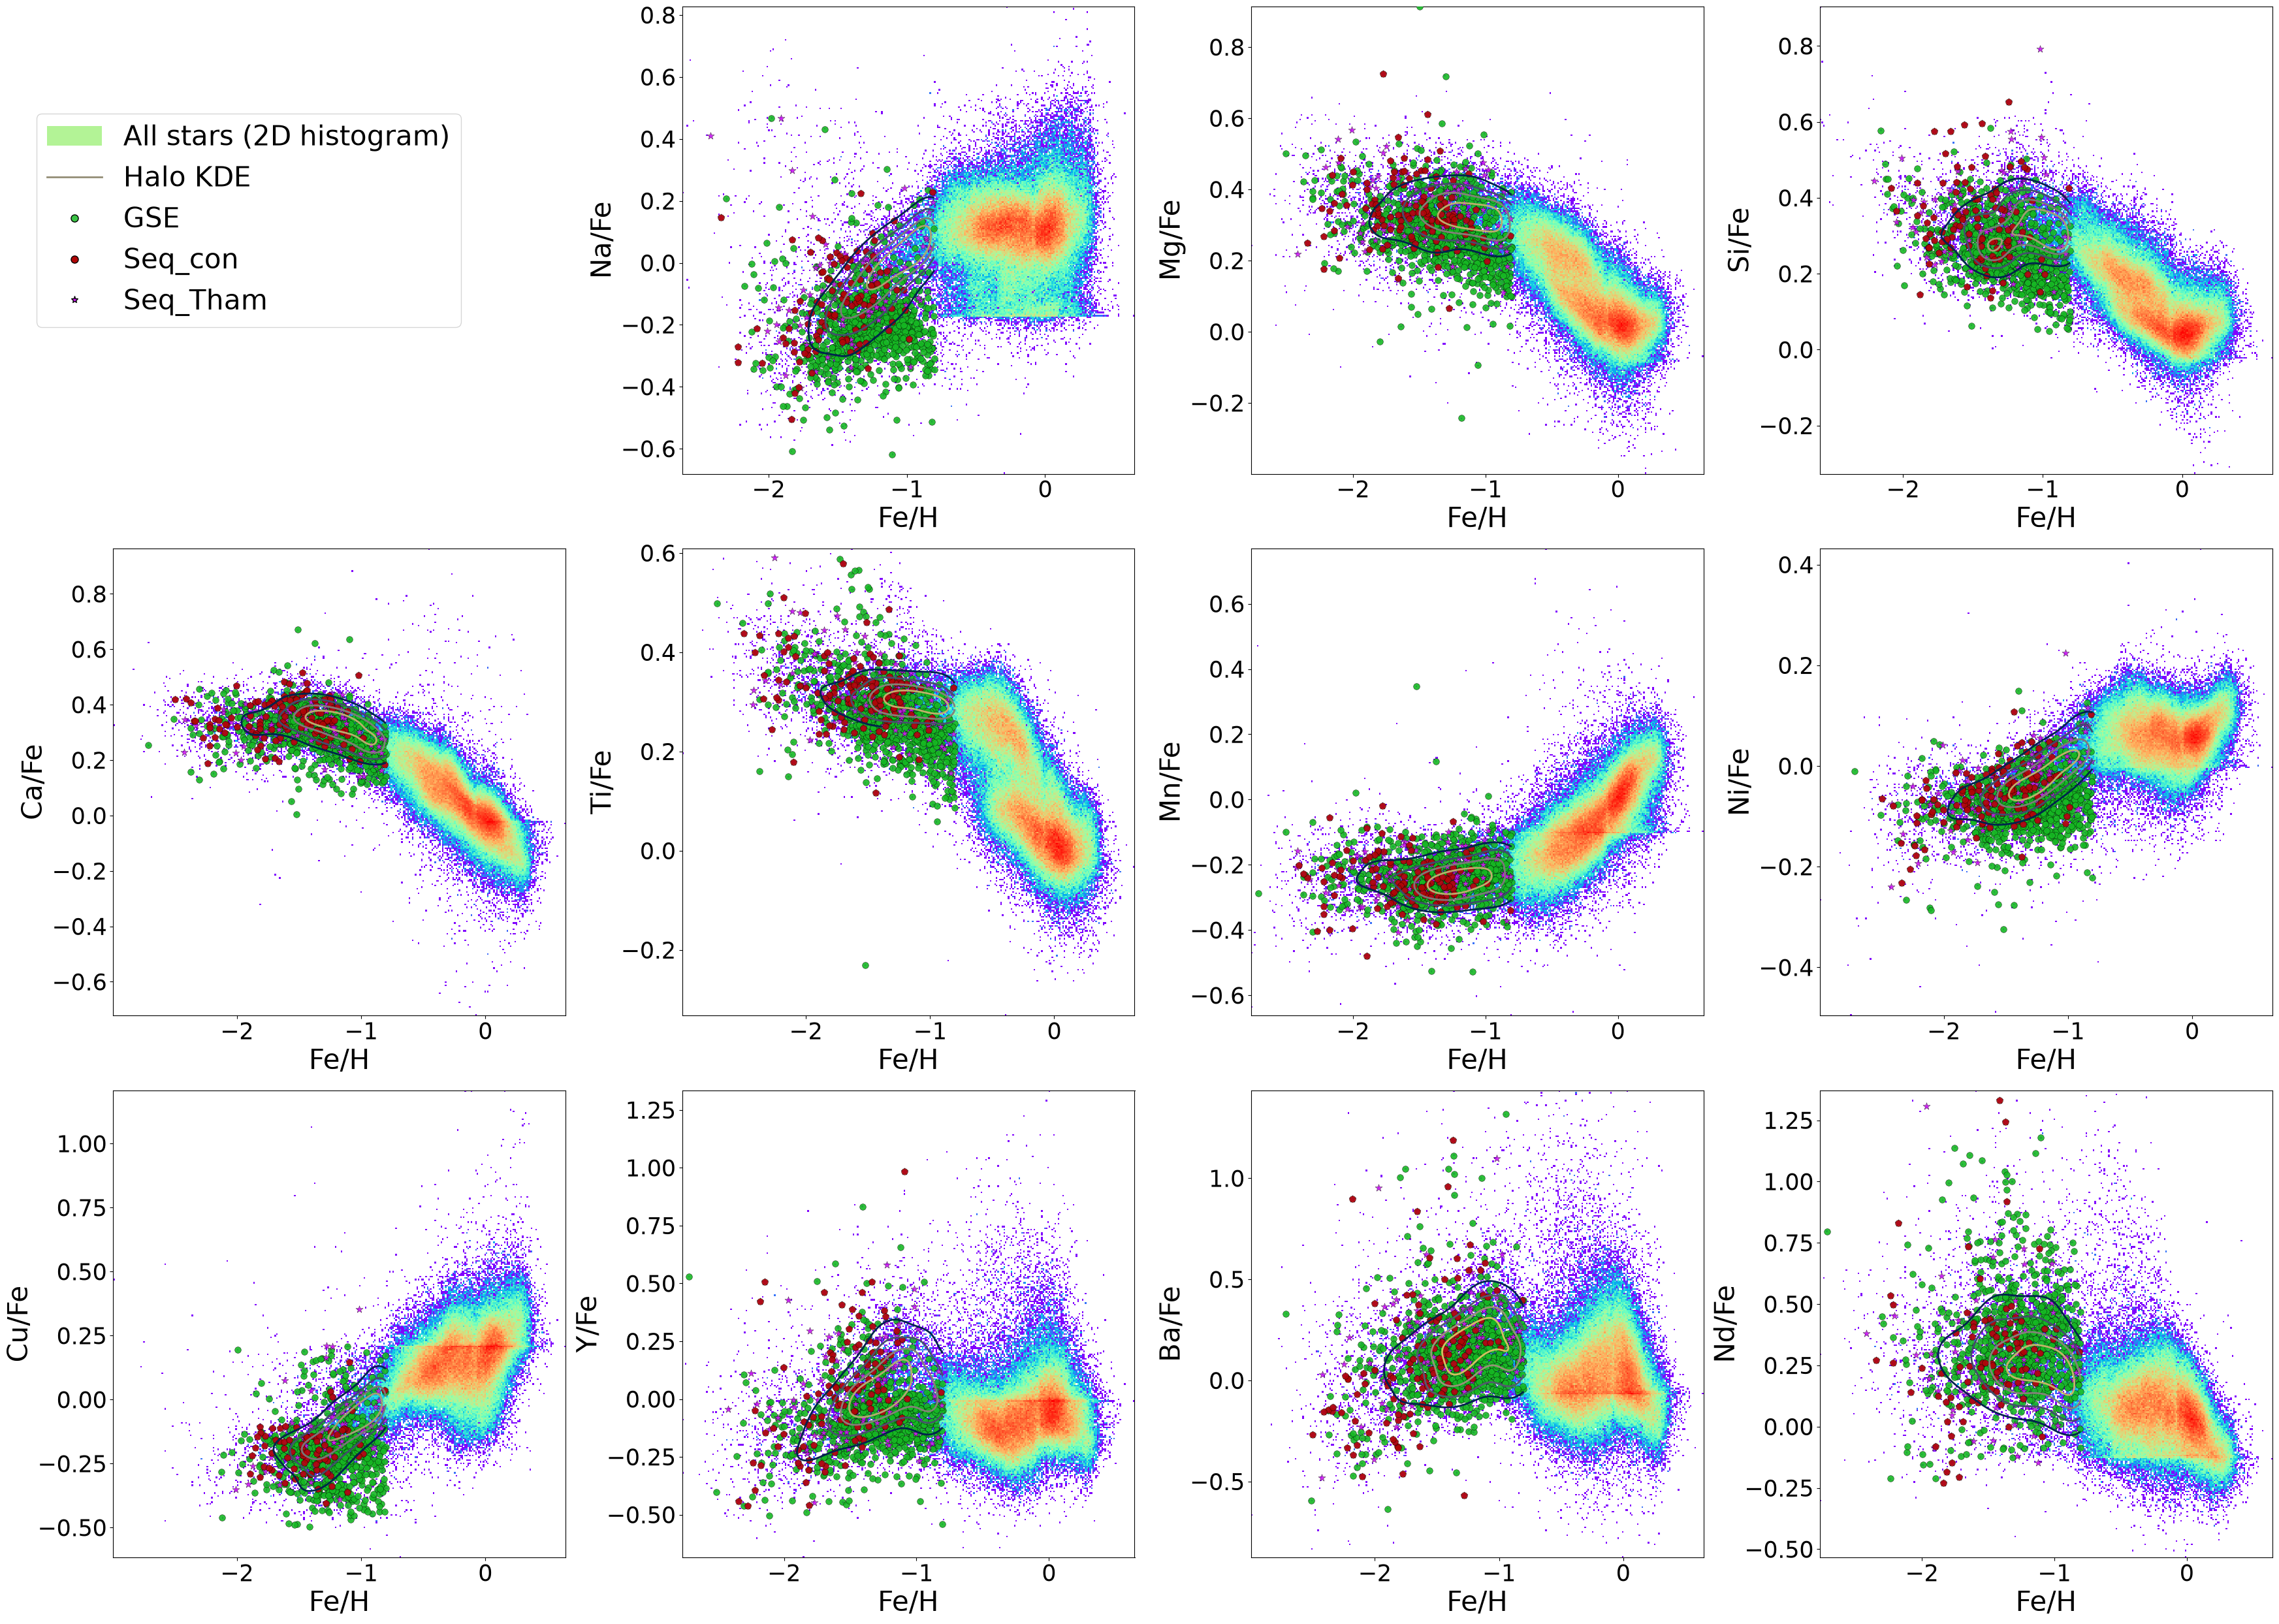

In [ ]:
# ============================================================
# Configuration
# ============================================================

num_rows = 3
num_col = 4

fig, ax = plt.subplots(
    num_rows,
    num_col,
    sharex=False,
    sharey=False,
    figsize=(35, 25)
)

fig.subplots_adjust(
    hspace=0.22,
    wspace=0.32
)

fontsize = 30
labelsize = 25

elm_x = 'fe_h'

elm_ys = [
    'na_fe',
    'mg_fe',
    'si_fe',
    'ca_fe',
    'ti_fe',
    'mn_fe',
    'ni_fe',
    'cu_fe',
    'y_fe',
    'ba_fe',
    'nd_fe'
]


# ============================================================
# Data
# ============================================================

All_df = galah_Gaia_new_ratios_nessessary_flags

datasets = {
    'Halo': {'df': Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags,
        'color': Halo_C,
        'marker': 'o',
        'size': 50,
        'zorder': 7,
    },

    'GSE': {
        'df': galah_Gaia_GSE_new_ratios_nessessary_flags,
        'color': GSE_C,
        'marker': 'o',
        'size': 50,
        'zorder': 4,
    },

    'Seq_con': {
        'df': galah_Gaia_Sequoia_new_ratios_nessessary_flags,
        'color': Sequoia_C,
        'marker': 'o',
        'size': 50,
        'zorder': 6,
    },

    'Seq_Tham': {
        'df': galah_Gaia_Sequoia_p_Thamnos_new_ratios_nessessary_flags,
        'color': Sequoia_C_2,
        'marker': '*',
        'size': 70,
        'zorder': 5,
    },
}


# ============================================================
# Display labels
# ============================================================

def ratio_label(ratio):
    """Convert e.g. 'mn_na' -> 'Mn/Na'."""
    return '/'.join(
        part.capitalize()
        for part in ratio.replace('_', '/').split('/')
    )


x_label = ratio_label(elm_x)


# ============================================================
# Plotting
# ============================================================

axes = ax.flatten()

# Reserve first panel for legend
legend_ax = axes[0]


for idx, elm_y in enumerate(elm_ys):

    target_ax = axes[idx + 1]

    y_label = ratio_label(elm_y)

    # --------------------------------------------------------
    # ALL STARS: 2D histogram
    # --------------------------------------------------------

    all_x = All_df[elm_x]
    all_y = All_df[elm_y]

    mask_all = all_x.notna() & all_y.notna()

    target_ax.hist2d(
        all_x.loc[mask_all],
        all_y.loc[mask_all],
        bins=300,
        cmap='rainbow',
        norm=LogNorm()
    )


    # --------------------------------------------------------
    # HALO: KDE contour
    # --------------------------------------------------------

    halo_df = datasets['Halo']['df']

    halo_x = halo_df[elm_x]
    halo_y = halo_df[elm_y]

    mask_halo = halo_x.notna() & halo_y.notna()

    sns.kdeplot(
        x=halo_x.loc[mask_halo],
        y=halo_y.loc[mask_halo],
        levels=5,
        cmap='cividis',
        thresh=0.3,
        fill=False,
        linewidths=2,
        cut=0,
        alpha=1.0,
        ax=target_ax,
        zorder = 7
    )


    # --------------------------------------------------------
    # POPULATION SCATTERS
    # --------------------------------------------------------

    for name, settings in datasets.items():

        # Halo is already plotted as KDE
        if name == 'Halo':
            continue

        df = settings['df']

        x = df[elm_x]
        y = df[elm_y]

        mask = x.notna() & y.notna()

        target_ax.scatter(
            x.loc[mask],
            y.loc[mask],
            s=settings['size'],
            alpha=0.9,
            c=settings['color'],
            marker=settings['marker'],
            edgecolors='k',
            linewidths=0.3,
            zorder=settings['zorder']
        )


    # --------------------------------------------------------
    # AXIS LABELS / TICKS
    # --------------------------------------------------------

    target_ax.set_xlabel(
        x_label,
        fontsize=fontsize
    )

    target_ax.set_ylabel(
        y_label,
        fontsize=fontsize
    )

    target_ax.tick_params(
        axis='x',
        labelsize=labelsize
    )

    target_ax.tick_params(
        axis='y',
        labelsize=labelsize
    )


# ============================================================
# Legend
# ============================================================

legend_ax.axis('off')

handles = [
    Patch(
        facecolor=plt.get_cmap('rainbow')(0.6),
        edgecolor='none',
        label='All stars (2D histogram)'
    ),

    Line2D(
        [],
        [],
        color=plt.get_cmap('cividis')(0.6),
        linewidth=2,
        label='Halo KDE'
    ),
]

# Add population markers automatically
for name, settings in datasets.items():

    if name == 'Halo':
        continue

    handles.append(
        Line2D(
            [0],
            [0],
            marker=settings['marker'],
            color='w',
            markerfacecolor=settings['color'],
            markeredgecolor='k',
            markersize=8,
            label=name
        )
    )


legend_ax.legend(
    handles=handles,
    fontsize=fontsize,
    loc='upper left',
    bbox_to_anchor=(-0.2, 0.8)
)


plt.tight_layout()


In [105]:
Seq_con_vs_Halo_energy_test[0:15]

,ratio 1,ratio 2,p_value,statistic,num in Halo_Pradosh,num in Seq_con,element_list
0,si_na,cu_ca,1.326185e-09,0.062420,1256,69,"['ca', 'cu', 'na', 'si']"
1,ca_na,cu_si,1.699690e-09,0.062893,1256,69,"['ca', 'cu', 'na', 'si']"
2,na_fe,cu_ca,2.622141e-09,0.061738,1256,69,"['ca', 'cu', 'fe', 'na']"
3,cu_fe,ca_na,3.351403e-09,0.062393,1256,69,"['ca', 'cu', 'fe', 'na']"
4,ni_na,cu_ca,4.101075e-09,0.054865,1256,69,"['ca', 'cu', 'na', 'ni']"
5,ti_na,cu_ca,4.553187e-09,0.060125,1256,69,"['ca', 'cu', 'na', 'ti']"
6,mg_na,cu_ca,6.569270e-09,0.060231,1256,69,"['ca', 'cu', 'mg', 'na']"
7,ca_na,cu_mg,6.619495e-09,0.061269,1256,69,"['ca', 'cu', 'mg', 'na']"
8,ca_na,cu_ti,6.898996e-09,0.059976,1256,69,"['ca', 'cu', 'na', 'ti']"
9,ni_si,cu_ca,7.731941e-09,0.049936,1256,69,"['ca', 'cu', 'ni', 'si']"


In [142]:
energy_test_dict = {
    "Seq_con vs Seq_Tham": Seq_con_vs_Seq_Tham_energy_test,
    "Seq_con vs Halo": Seq_con_vs_Halo_energy_test,
    "Seq_Tham vs Halo": Seq_Tham_vs_Halo_energy_test,
    "Seq_con vs GSE": Seq_con_vs_GSE_energy_test,
    "Seq_Tham vs GSE": Seq_Tham_vs_GSE_energy_test,
    "GSE vs Halo": GSE_vs_Halo_energy_test
}

percents = [0.10]
for percent in percents:
    n = math.ceil(len(next(iter(energy_test_dict.values()))) * percent)
    print(f'{n} rows for {percent*100}% of the sample size')

    elm_frequency_table = {}
    for name, energy_test in energy_test_dict.items():
        print(f"Energy test for {name}:")
        elm_frequency_table[name] = energy_tests_best_elements(energy_test_dict[name], name, element_list, n=n, percents = False)
        
    elm_frequency_table = reduce(lambda left, right: pd.merge(left, right, on='elm', how='outer'), elm_frequency_table.values())

    costom_index = []
    # costom_index.append('xi_sq_statistic')
    costom_index.append('xi_sq_p_value')
    for elm in element_list:
        costom_index.append(elm)
    elm_frequency_table = (
        elm_frequency_table
        .set_index("elm")
        .reindex(costom_index)
        .reset_index()
    )

    with pd.option_context('display.float_format', lambda x: f'{x:.3g}'):
        display(HTML(elm_frequency_table.to_html(index=False)))





149 rows for 10.0% of the sample size
Energy test for Seq_con vs Seq_Tham:
49.666666666666664
Energy test for Seq_con vs Halo:
49.666666666666664
Energy test for Seq_Tham vs Halo:
49.666666666666664
Energy test for Seq_con vs GSE:
49.666666666666664
Energy test for Seq_Tham vs GSE:
49.666666666666664
Energy test for GSE vs Halo:
49.666666666666664


elm,Seq_con vs Seq_Tham frequency,Seq_con vs Halo frequency,Seq_Tham vs Halo frequency,Seq_con vs GSE frequency,Seq_Tham vs GSE frequency,GSE vs Halo frequency
xi_sq_p_value,1.75e-43,1.86e-47,6.92e-44,1.24e-28,1.23e-37,2.86e-39
fe,55,54,56,63,58,65
na,43,70,93,61,79,120
mg,34,46,56,27,30,32
si,29,52,74,58,62,32
ca,117,97,70,44,28,32
ti,56,45,49,40,37,34
mn,34,31,41,65,46,60
ni,52,49,54,31,38,37
cu,108,119,94,19,21,29


In [107]:
xi_sq_value = []
idx = []
for i in range(1,len(Seq_con_vs_Seq_Tham_energy_test)):
    idx.append(i)
    stuff_results = energy_tests_best_elements(Seq_con_vs_Seq_Tham_energy_test, 'Seq_con/Halo', element_list, n=i, percents = False)
    costom_index = []
        # costom_index.append('xi_sq_statistic')
    costom_index.append('xi_sq_p_value')
    stuff_results = (
            stuff_results
            .set_index("elm")
            .reindex(costom_index)
            .reset_index()
        )
    xi_sq_value.append(stuff_results['Seq_con/Halo frequency'][0])

0.3333333333333333
0.6666666666666666
1.0
1.3333333333333333
1.6666666666666667
2.0
2.3333333333333335
2.6666666666666665
3.0
3.3333333333333335
3.6666666666666665
4.0
4.333333333333333
4.666666666666667
5.0
5.333333333333333
5.666666666666667
6.0
6.333333333333333
6.666666666666667
7.0
7.333333333333333
7.666666666666667
8.0
8.333333333333334
8.666666666666666
9.0
9.333333333333334
9.666666666666666
10.0
10.333333333333334
10.666666666666666
11.0
11.333333333333334
11.666666666666666
12.0
12.333333333333334
12.666666666666666
13.0
13.333333333333334
13.666666666666666
14.0
14.333333333333334
14.666666666666666
15.0
15.333333333333334
15.666666666666666
16.0
16.333333333333332
16.666666666666668
17.0
17.333333333333332
17.666666666666668
18.0
18.333333333333332
18.666666666666668
19.0
19.333333333333332
19.666666666666668
20.0
20.333333333333332
20.666666666666668
21.0
21.333333333333332
21.666666666666668
22.0
22.333333333333332
22.666666666666668
23.0
23.333333333333332
23.6666666666

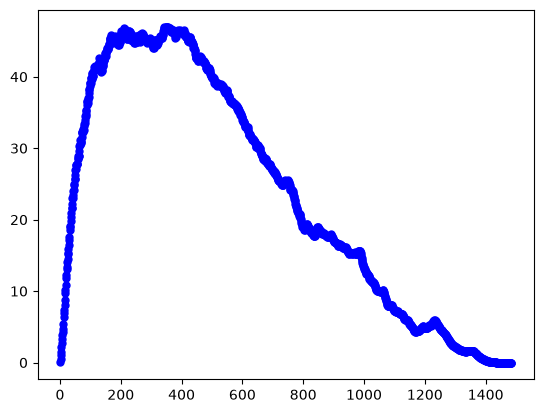

In [108]:
plt.plot(idx, -np.log10(xi_sq_value), marker='o', markersize=5, color='blue', label='Seq_con/Halo')

elm_x: si_na and elm_y: cu_ca
elm_x: ca_na and elm_y: cu_si
elm_x: na_fe and elm_y: cu_ca
elm_x: cu_fe and elm_y: ca_na
elm_x: ni_na and elm_y: cu_ca
elm_x: ca_na and elm_y: cu_si
elm_x: cu_fe and elm_y: si_na
elm_x: si_na and elm_y: cu_mn
elm_x: si_na and elm_y: cu_ca
elm_x: na_fe and elm_y: cu_si


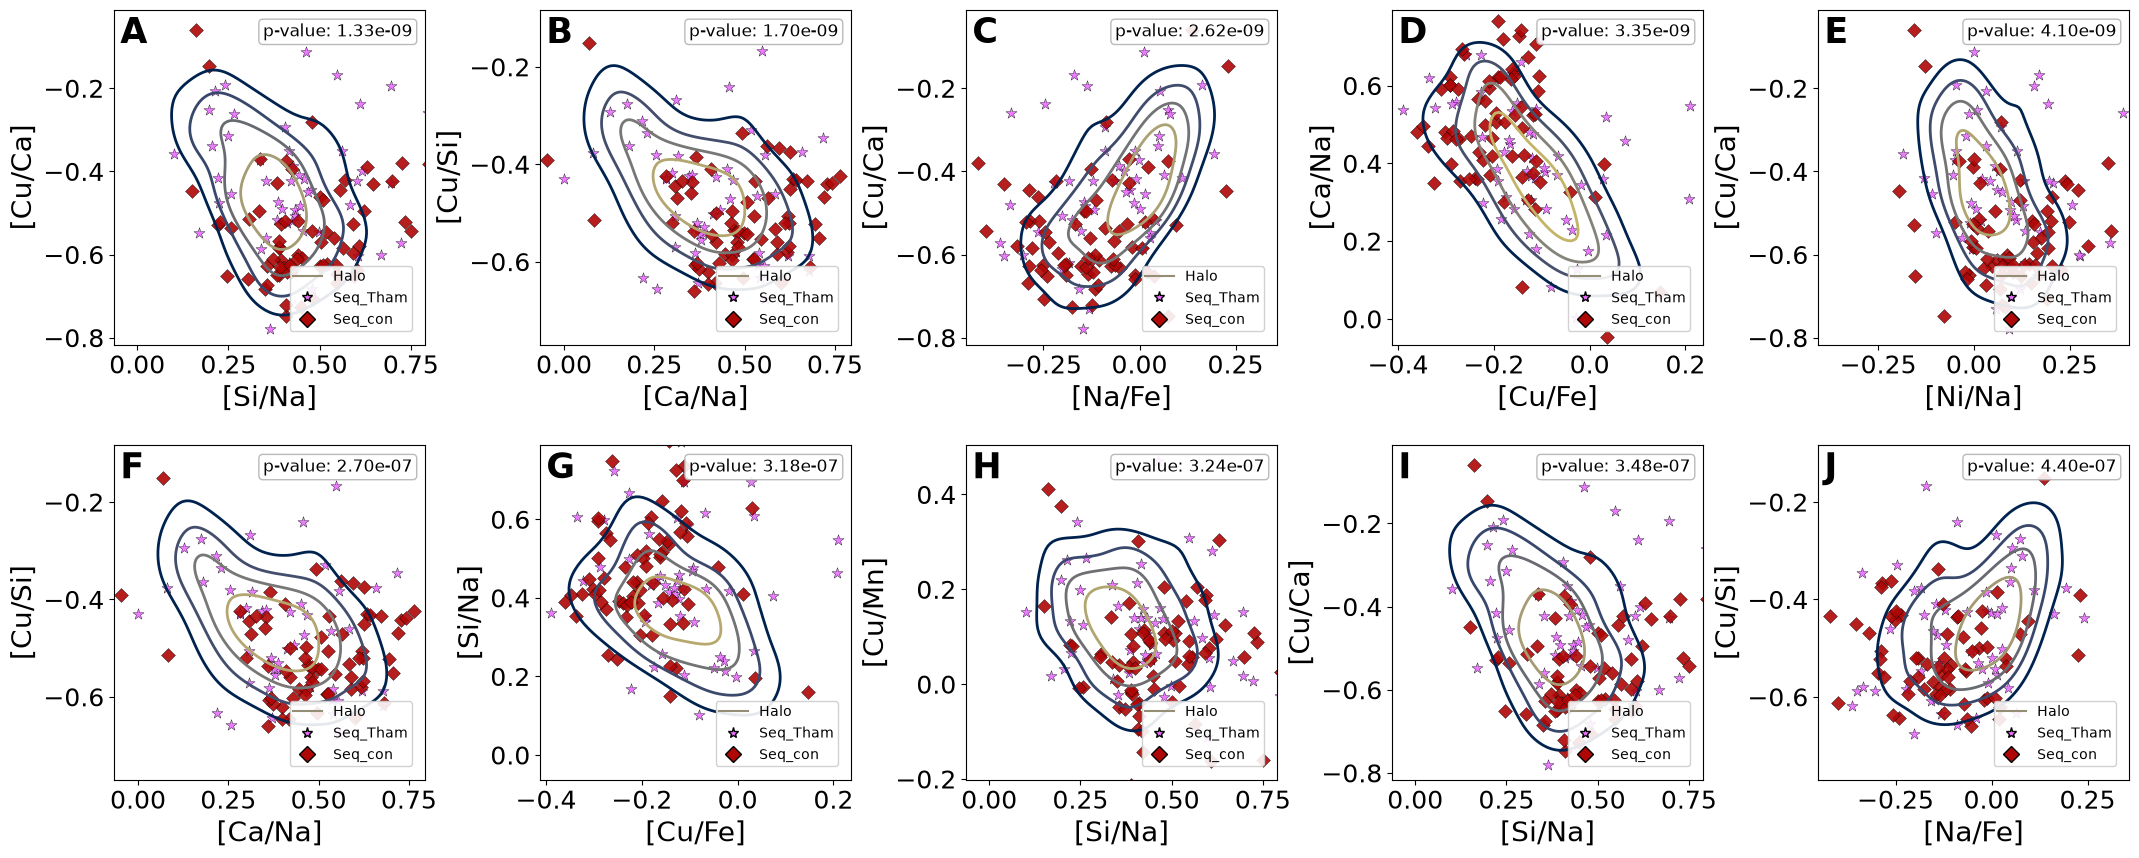

In [150]:
num_rows = 2
num_col = 5
fig, ax = plt.subplots(num_rows, num_col, sharex=False, sharey=False, figsize=(26, 10)) # was 20,25
fig.subplots_adjust(hspace=0.30, wspace=0.37) # was 0.3 and 0.25
# plt.tight_layout()
fontsize = 20
labelsize = 18

axes = ax.flatten()
# legend_ax = axes[0]



ref_df = galah_Gaia_Halo_new_ratios
ref_color = Halo_C
ref_name = 'Halo'
ref_cmap = 'cividis'

Seq_con_VS_Halo = [
    ['cu_ca', 'si_na',1.326185e-09,'A',],
    ['cu_ca', 'na_fe',2.622141e-09,'B',],
    ['cu_ca', 'ni_na',4.101075e-09,'C',],
    ['cu_ca', 'ti_na',4.553187e-09,'D',],
    ['cu_ca', 'mg_na',6.569270e-09,'E',],
]

Seq_Tham_VS_Halo = [
    ['cu_si', 'ca_na',2.704988e-07,'F',],
    ['cu_fe', 'si_na',3.182597e-07,'G',],
    ['cu_mn', 'si_na',3.241511e-07,'H',],
    ['cu_mg', 'si_na',5.613310e-07,'I',],
    ['cu_si', 'ti_ca',8.955257e-07,'J',],
]

df = Seq_con_vs_Halo_energy_test
Seq_con_VS_Halo = [
    [df['ratio 1'].iloc[0], df['ratio 2'].iloc[0], df['p_value'].iloc[0], 'A'],
    [df['ratio 1'].iloc[1], df['ratio 2'].iloc[1], df['p_value'].iloc[1], 'B'],
    [df['ratio 1'].iloc[2], df['ratio 2'].iloc[2], df['p_value'].iloc[2], 'C'],
    [df['ratio 1'].iloc[3], df['ratio 2'].iloc[3], df['p_value'].iloc[3], 'D'],
    [df['ratio 1'].iloc[4], df['ratio 2'].iloc[4], df['p_value'].iloc[4], 'E'],
]

df = Seq_Tham_vs_Halo_energy_test
Seq_Tham_VS_Halo = [
    [df['ratio 1'].iloc[0], df['ratio 2'].iloc[0], df['p_value'].iloc[0], 'F'],
    [df['ratio 1'].iloc[1], df['ratio 2'].iloc[1], df['p_value'].iloc[1], 'G'],
    [df['ratio 1'].iloc[2], df['ratio 2'].iloc[2], df['p_value'].iloc[2], 'H'],
    [df['ratio 1'].iloc[3], df['ratio 2'].iloc[3], df['p_value'].iloc[3], 'I'],
    [df['ratio 1'].iloc[4], df['ratio 2'].iloc[4], df['p_value'].iloc[4], 'J'],
]

Seq_dict = {
    # 'Halo': (Halo_Pradosh_galah_Gaia_new_ratios, Halo_C, '.'),
    'Seq_Tham': (galah_Gaia_Sequoia_p_Thamnos_new_ratios, Sequoia_C_2, '*', 70),
    'Seq_con': (galah_Gaia_Sequoia_new_ratios, Sequoia_C, 'D', 50),
    # 'Tham2': (galah_Gaia_Thamnos2_new_ratios, thamnos_2_C, 'D', 90),

}

for row, elm_combos in enumerate([Seq_con_VS_Halo, Seq_Tham_VS_Halo]):

    for idx, elm_combos in enumerate(elm_combos):
    
        target_ax = ax[row, idx]  # select the subplot at this row and column
        handles = []

        elm_x = elm_combos[0]
        elm_y = elm_combos[1]
        p_value = elm_combos[2]
        letter = elm_combos[3]
        print(f'elm_x: {elm_x} and elm_y: {elm_y}')
        elm_lable_x_display = '/'.join([seg.capitalize() for seg in elm_x.replace('_', '/').split('/')])
        elm_lable_y_display = '/'.join([seg.capitalize() for seg in elm_y.replace('_', '/').split('/')])
        
        x_values = []
        y_values = []


        


        ############################################
        # all (2D histogram)
        # all_x = All_df[elm_x]
        # all_y = All_df[elm_y]
        # mask_all = all_x.notna() & all_y.notna()

        # cmap = plt.get_cmap("rainbow")
        # target_ax.hist2d(all_x[mask_all], all_y[mask_all], bins=300, cmap=cmap, norm=LogNorm())
        
            ################
        #all stars contours
        
        # sns.kdeplot(
        #     x=all_x,
        #     y=all_y,
        #     levels=5,
        #     cmap='cool',
        #     thresh=0.05,
        #     fill=False,
        #     linewidths=1.5,
        #     cut=0,
        #     alpha=0.9,
        #     ax=target_ax
        # )

        ##################
        
        # Ref (2D histogram)
        ref_x = ref_df[elm_x]
        ref_y = ref_df[elm_y]
        mask_ref = ref_x.notna() & ref_y.notna()
        x_values.extend(ref_df.loc[mask_ref, elm_x].dropna().values)
        y_values.extend(ref_df.loc[mask_ref, elm_y].dropna().values)

        # cmap = plt.get_cmap("viridis")
        # target_ax.hist2d(ref_x[mask_ref], ref_y[mask_ref], bins=30, cmap=cmap, norm=LogNorm())
        # target_ax.scatter(ref_df.loc[mask_ref, elm_x], ref_df.loc[mask_ref, elm_y],
        #                   s=50, alpha=0.9, label='Halo', c=ref_color, edgecolors='k', linewidths=0.3)

        handles.append(Line2D( [], [], color=plt.get_cmap(ref_cmap)(0.6), linewidth=1.5, label=ref_name))
        sns.kdeplot(
                    x=ref_df.loc[mask_ref, elm_x],
                    y=ref_df.loc[mask_ref, elm_y],
                    levels=5,
                    cmap=ref_cmap,
                    thresh=0.3,
                    fill=False,
                    linewidths=2,
                    cut=0,
                    alpha=1.0,
                    ax=target_ax
                )

    ###################################    
        
        # Sequoia scatter
        
        for name, (df, color, shape, size) in Seq_dict.items():
            mask_df = df[elm_x].notna() & df[elm_y].notna()
            target_ax.scatter(df.loc[mask_df, elm_x], df.loc[mask_df, elm_y],
                            s=size, alpha=0.9, c=color, marker = shape, edgecolors='k', linewidths=0.3)
            handles.append(Line2D([0], [0], marker=shape, color='none', markerfacecolor=color, markeredgecolor='k', markersize=8, label=name))

            # sns.kdeplot(
            #         x=df.loc[mask_df, elm_x],
            #         y=df.loc[mask_df, elm_y],
            #         levels=5,
            #         cmap='inferno',
            #         thresh=0.1,
            #         fill=False,
            #         linewidths=1.5,
            #         cut=0,
            #         alpha=0.9,
            #         ax=target_ax,
            #         zorder=6
            #     )
            
            x_values.extend(df.loc[mask_df, elm_x].dropna().values)
            y_values.extend(df.loc[mask_df, elm_y].dropna().values)


        #############################################
        x_values = np.asarray(x_values)
        y_values = np.asarray(y_values)

        # Use percentiles instead of min/max
        x_low, x_high = np.percentile(x_values, [1, 99])
        y_low, y_high = np.percentile(y_values, [1, 99])

        # Add some padding
        x_pad = 0.05 * (x_high - x_low)
        y_pad = 0.05 * (y_high - y_low)
        target_ax.set_xlim(x_low - x_pad, x_high + x_pad)
        target_ax.set_ylim(y_low - y_pad, y_high + y_pad)
        
        #########################################
        target_ax.text(0.02, 0.98, f'{letter}', transform=target_ax.transAxes, fontsize=fontsize+5, fontweight='bold', va='top', ha='left')
        target_ax.set_xlabel(f'[{elm_lable_x_display}]', fontsize = fontsize)
        target_ax.set_ylabel(f'[{elm_lable_y_display}]', fontsize = fontsize)
        target_ax.tick_params(axis='x', labelsize=labelsize)
        target_ax.tick_params(axis='y', labelsize=labelsize)
        
        target_ax.text(
            0.96, 0.96,
            f"p-value: {p_value:.2e}",
            transform=target_ax.transAxes,
            ha="right",
            va="top",
            fontsize=labelsize/1.5,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.9),
        )


        target_ax.legend(
            handles=handles,
            fontsize=labelsize/1.75,
            loc="lower right",
            bbox_to_anchor=(0.98, 0.02),
            frameon=True,
            fancybox=True,
            borderpad=0.25,
            framealpha=0.9,
            )


elm_x: ca_fe and elm_y: nd_y
elm_x: si_fe and elm_y: nd_y
elm_x: mn_si and elm_y: nd_y
elm_x: mn_ca and elm_y: nd_y
elm_x: ti_fe and elm_y: nd_y
elm_x: si_fe and elm_y: nd_y
elm_x: mn_na and elm_y: nd_y
elm_x: na_fe and elm_y: nd_y
elm_x: mn_si and elm_y: nd_y
elm_x: mg_fe and elm_y: nd_y


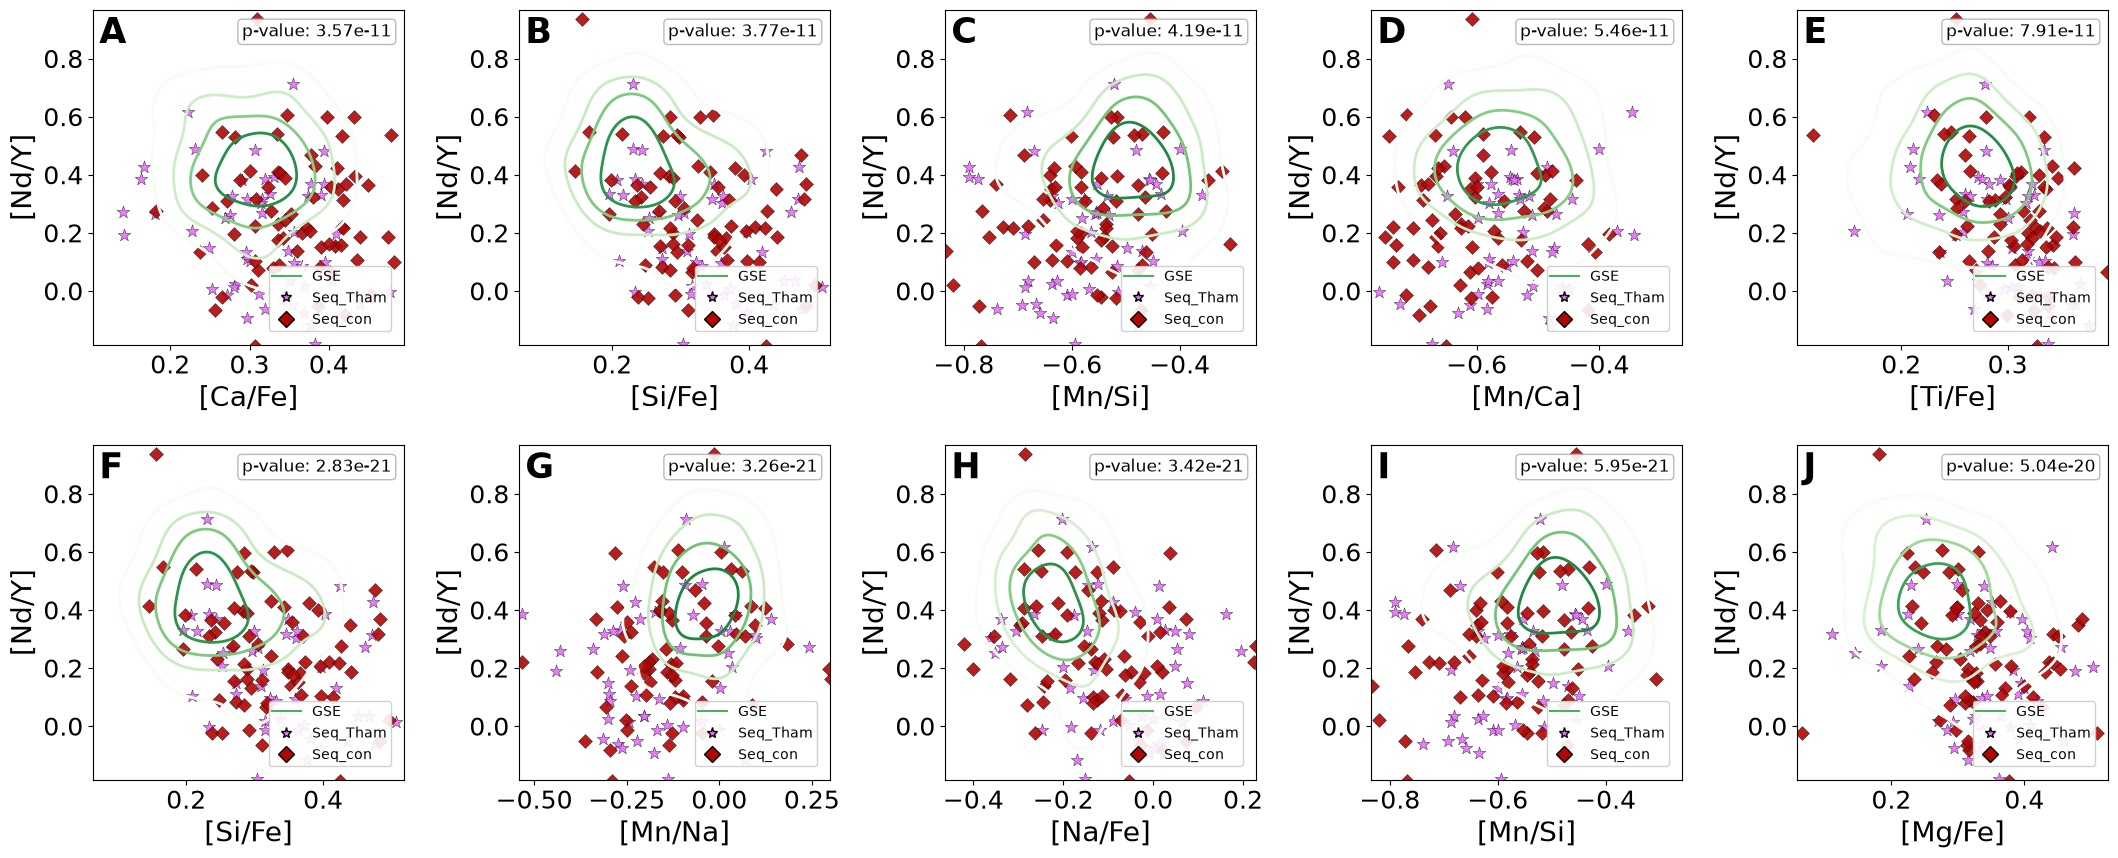

In [151]:
num_rows = 2
num_col = 5
fig, ax = plt.subplots(num_rows, num_col, sharex=False, sharey=False, figsize=(26, 10)) # was 20,25
fig.subplots_adjust(hspace=0.30, wspace=0.37) # was 0.3 and 0.25
# plt.tight_layout()
fontsize = 20
labelsize = 18

axes = ax.flatten()
# legend_ax = axes[0]



ref_df = galah_Gaia_GSE_new_ratios
ref_color = GSE_C
ref_shape = 'o'
ref_name = 'GSE'
ref_cmap = 'Greens'


# Seq_con_VS_GSE = [
#     ['nd_y', 'ca_fe',3.574621e-11,'A'],
#     ['nd_y', 'si_fe',3.770271e-11,'B'],
#     ['nd_y', 'mn_si',4.186216e-11,'C'],
#     ['nd_y', 'mn_ca',5.462752e-11,'D'],
#     ['nd_y', 'ti_fe',7.911154e-11,'E'],
# ]

# Seq_Tham_VS_GSE = [
#     ['nd_y', 'si_fe', 2.834059e-21,'F'],
#     ['nd_y', 'mn_na', 3.256544e-21,'G'],
#     ['nd_y', 'na_fe', 3.421999e-21,'H'],
#     ['nd_y', 'mn_si', 5.950748e-21,'I'],
#     ['nd_y', 'mg_fe', 5.043463e-20,'J'],
# ]

df = Seq_con_vs_GSE_energy_test
Seq_con_VS_GSE = [
    [df['ratio 1'].iloc[0], df['ratio 2'].iloc[0], df['p_value'].iloc[0], 'A'],
    [df['ratio 1'].iloc[1], df['ratio 2'].iloc[1], df['p_value'].iloc[1], 'B'],
    [df['ratio 1'].iloc[2], df['ratio 2'].iloc[2], df['p_value'].iloc[2], 'C'],
    [df['ratio 1'].iloc[3], df['ratio 2'].iloc[3], df['p_value'].iloc[3], 'D'],
    [df['ratio 1'].iloc[4], df['ratio 2'].iloc[4], df['p_value'].iloc[4], 'E'],
]

df = Seq_Tham_vs_GSE_energy_test
Seq_Tham_VS_GSE = [
    [df['ratio 1'].iloc[0], df['ratio 2'].iloc[0], df['p_value'].iloc[0], 'F'],
    [df['ratio 1'].iloc[1], df['ratio 2'].iloc[1], df['p_value'].iloc[1], 'G'],
    [df['ratio 1'].iloc[2], df['ratio 2'].iloc[2], df['p_value'].iloc[2], 'H'],
    [df['ratio 1'].iloc[3], df['ratio 2'].iloc[3], df['p_value'].iloc[3], 'I'],
    [df['ratio 1'].iloc[4], df['ratio 2'].iloc[4], df['p_value'].iloc[4], 'J'],
]

Seq_dict = {
    # 'Halo': (Halo_Pradosh_galah_Gaia_new_ratios, Halo_C, '.'),
    'Seq_Tham': (galah_Gaia_Sequoia_p_Thamnos_new_ratios, Sequoia_C_2, '*', 90),
    'Seq_con': (galah_Gaia_Sequoia_new_ratios, Sequoia_C, 'D', 50),

}

for row, elm_combos in enumerate([Seq_con_VS_GSE, Seq_Tham_VS_GSE]):

    for idx, elm_combos in enumerate(elm_combos):
    
        target_ax = ax[row, idx]  # select the subplot at this row and column
        handles = []

        elm_x = elm_combos[0]
        elm_y = elm_combos[1]
        p_value = elm_combos[2]
        letter = elm_combos[3]
        print(f'elm_x: {elm_x} and elm_y: {elm_y}')
        elm_lable_x_display = '/'.join([seg.capitalize() for seg in elm_x.replace('_', '/').split('/')])
        elm_lable_y_display = '/'.join([seg.capitalize() for seg in elm_y.replace('_', '/').split('/')])
        
        x_values = []
        y_values = []


        


        ############################################
        # all (2D histogram)
        # all_x = All_df[elm_x]
        # all_y = All_df[elm_y]
        # mask_all = all_x.notna() & all_y.notna()

        # cmap = plt.get_cmap("rainbow")
        # target_ax.hist2d(all_x[mask_all], all_y[mask_all], bins=300, cmap=cmap, norm=LogNorm())
        
            ################
        #all stars contours
        
        # sns.kdeplot(
        #     x=all_x,
        #     y=all_y,
        #     levels=5,
        #     cmap='cool',
        #     thresh=0.05,
        #     fill=False,
        #     linewidths=1.5,
        #     cut=0,
        #     alpha=0.9,
        #     ax=target_ax
        # )

        ##################
        
        # Ref (2D histogram)
        ref_x = ref_df[elm_x]
        ref_y = ref_df[elm_y]
        mask_ref = ref_x.notna() & ref_y.notna()
        x_values.extend(ref_df.loc[mask_ref, elm_x].dropna().values)
        y_values.extend(ref_df.loc[mask_ref, elm_y].dropna().values)

        # cmap = plt.get_cmap("viridis")
        # target_ax.hist2d(ref_x[mask_ref], ref_y[mask_ref], bins=30, cmap=cmap, norm=LogNorm())
        # target_ax.scatter(ref_df.loc[mask_ref, elm_x], ref_df.loc[mask_ref, elm_y],
        #                   s=50, alpha=0.9, label='Halo', c=ref_color, edgecolors='k', linewidths=0.3)

        
        handles.append(Line2D( [], [], color=plt.get_cmap(ref_cmap)(0.6), linewidth=1.5, label=ref_name))
        sns.kdeplot(
                    x=ref_df.loc[mask_ref, elm_x],
                    y=ref_df.loc[mask_ref, elm_y],
                    levels=5,
                    cmap=ref_cmap,
                    thresh=0.2,
                    fill=False,
                    linewidths=2,
                    cut=0,
                    alpha=1.0,
                    ax=target_ax
                )

    ###################################    
        
        # Sequoia scatter
        
        for name, (df, color, shape, size) in Seq_dict.items():
            mask_df = df[elm_x].notna() & df[elm_y].notna()
            target_ax.scatter(df.loc[mask_df, elm_x], df.loc[mask_df, elm_y],
                            s=size, alpha=0.9, c=color, marker = shape, edgecolors='k', linewidths=0.3)
            handles.append(Line2D([0], [0], marker=shape, color='none', markerfacecolor=color, markeredgecolor='k', markersize=8, label=name))

            # sns.kdeplot(
            #         x=df.loc[mask_df, elm_x],
            #         y=df.loc[mask_df, elm_y],
            #         levels=5,
            #         cmap='inferno',
            #         thresh=0.1,
            #         fill=False,
            #         linewidths=1.5,
            #         cut=0,
            #         alpha=0.9,
            #         ax=target_ax,
            #         zorder=6
            #     )
            
            x_values.extend(df.loc[mask_df, elm_x].dropna().values)
            y_values.extend(df.loc[mask_df, elm_y].dropna().values)


        #############################################
        x_values = np.asarray(x_values)
        y_values = np.asarray(y_values)

        # Use percentiles instead of min/max
        x_low, x_high = np.percentile(x_values, [1, 99])
        y_low, y_high = np.percentile(y_values, [1, 99])

        # Add some padding
        x_pad = 0.05 * (x_high - x_low)
        y_pad = 0.05 * (y_high - y_low)
        target_ax.set_xlim(x_low - x_pad, x_high + x_pad)
        target_ax.set_ylim(y_low - y_pad, y_high + y_pad)
        
        #########################################
        target_ax.text(0.02, 0.98, f'{letter}', transform=target_ax.transAxes, fontsize=fontsize+5, fontweight='bold', va='top', ha='left')
        target_ax.set_xlabel(f'[{elm_lable_x_display}]', fontsize = fontsize)
        target_ax.set_ylabel(f'[{elm_lable_y_display}]', fontsize = fontsize)
        target_ax.tick_params(axis='x', labelsize=labelsize)
        target_ax.tick_params(axis='y', labelsize=labelsize)
        
        target_ax.text(
            0.96, 0.96,
            f"p-value: {p_value:.2e}",
            transform=target_ax.transAxes,
            ha="right",
            va="top",
            fontsize=labelsize/1.5,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.9),
        )


        target_ax.legend(
            handles=handles,
            fontsize=labelsize/1.75,
            loc="lower right",
            bbox_to_anchor=(0.98, 0.02),
            frameon=True,
            fancybox=True,
            borderpad=0.25,
            framealpha=0.9,
            )


0 and 0 and 0
-0.48504502000000005
0.09300036
0.12765932168
1 and 1 and 0
-0.57452718
0.11348236480000001
0.10106776
2 and 2 and 0
-0.42730947999999996
0.1305296944
0.1610301096
3 and 0 and 1
-0.43639595
0.13310552720000002
0.10956492764800001
4 and 1 and 1
-0.313172617
0.11933375896
0.12201408
5 and 2 and 1
-0.53349127
0.14132326
0.1187978856
6 and 0 and 2
-0.87034861
0.1197358592
0.1332967648
7 and 1 and 2
-1.01424672
0.159804296
0.12005073280000002
8 and 2 and 2
-0.7889738550000001
0.154712822
0.10473645040000001


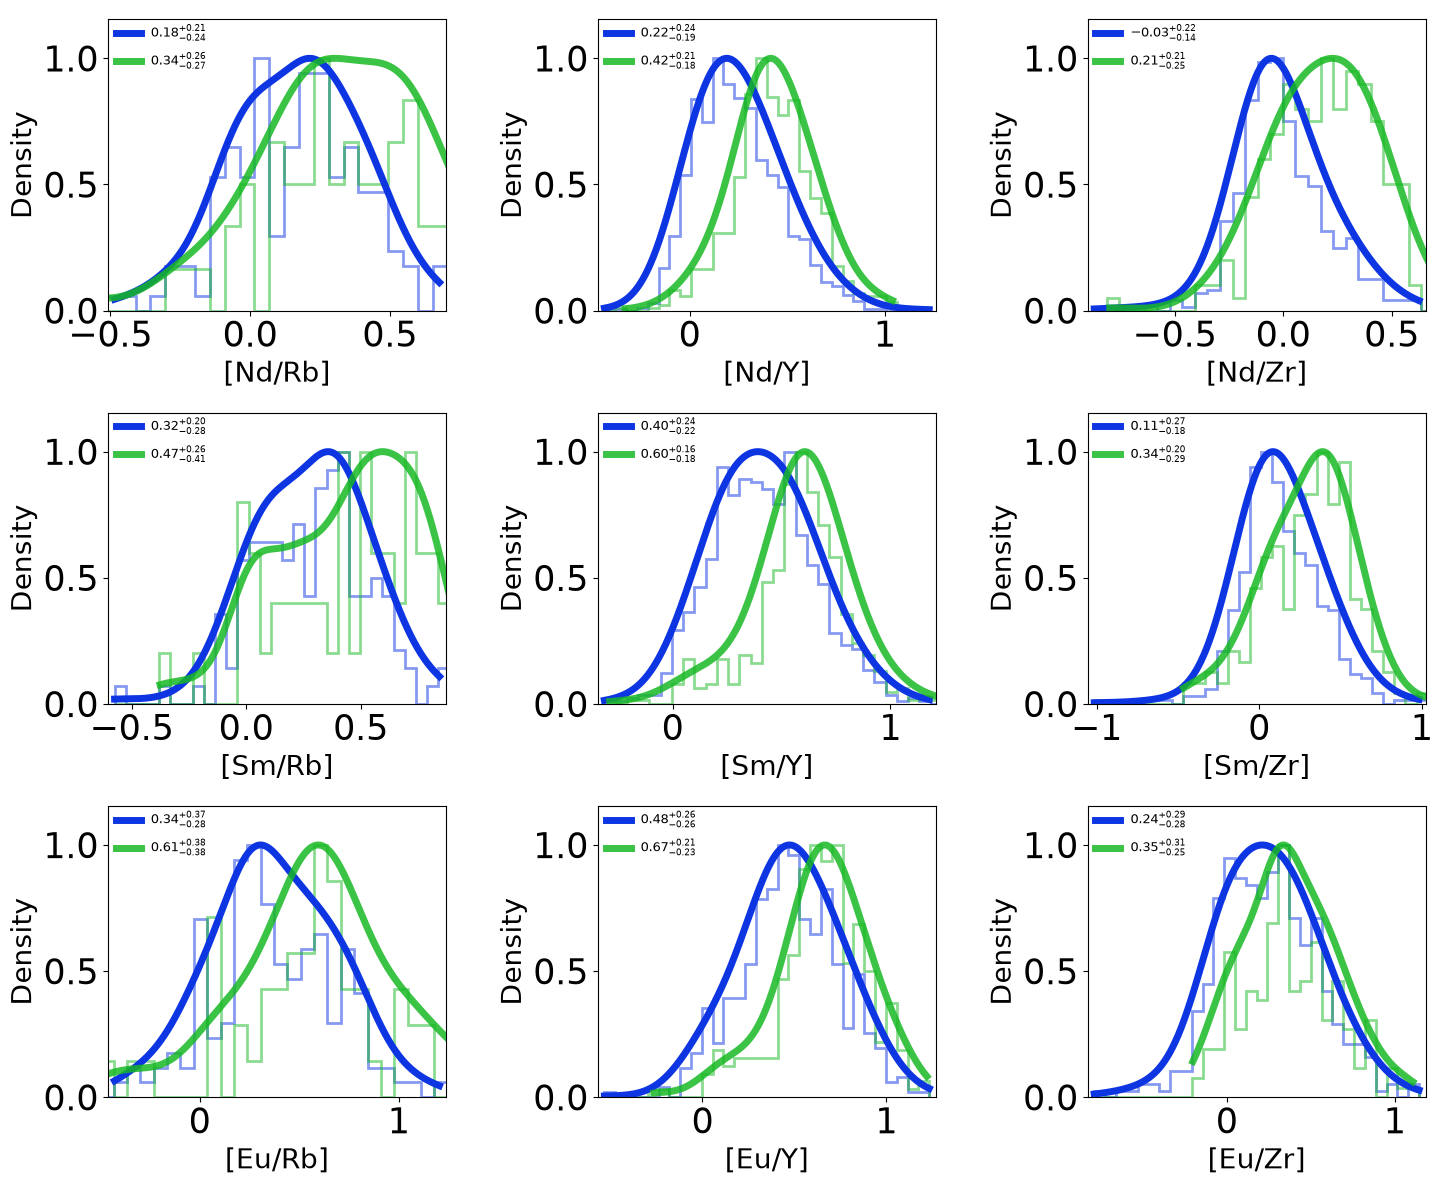

In [111]:
num_bins = 50
percentiles = [16, 50, 84]

elm_ratios = ['nd_rb', 'sm_rb', 'eu_rb', 'nd_y', 'sm_y', 'eu_y','nd_zr', 'sm_zr', 'eu_zr',] # r/s1 # all show GSE having a higher dex
# elm_ratios = ['nd_ba', 'sm_ba', 'eu_ba', 'nd_la', 'sm_la', 'eu_la','nd_ce', 'sm_ce', 'eu_ce',] # r/s2 Ba acts like s1, la and ce act like r
# elm_ratios = ['ba_rb', 'la_rb', 'ce_rb', 'ba_y', 'la_y', 'ce_y', 'ba_zr', 'la_zr', 'ce_zr',] # s2/s1 # again Ba acts like s1 while la and ce act like r

# elm_ratios = ['fe_h']

# Datasets mapping: name -> (dataframe_with_columns, color)
# datasets = {
#     'Sec': (galah_Gaia_Sequoia_new_ratios, Sequoia_C, 'solid', ':'),
#     'GSE': (galah_Gaia_GSE_new_ratios, GSE_C,  'solid', ':'),
#     'Halo': (Halo_Pradosh_galah_Gaia_new_ratios, Halo_C, 'solid', ':'),
#     # 'Tham1': (galah_Gaia_Thamnos_1_new_ratios, thamnos_1_C, 'solid', ':'),
#     # 'Tham2': (galah_Gaia_Thamnos_2_new_ratios, thamnos_2_C,  'solid', ':'),
# }

datasets = {
    'Halo': (Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags, Halo_C,  'solid', ':'),
    'GSE': (galah_Gaia_GSE_new_ratios_nessessary_flags, GSE_C,  'solid', ':'),
    # 'Seq': (galah_Gaia_Sequoia_new_ratios_nessessary_flags, Sequoia_C,  'solid', ':'),
    # 'Tham1': (galah_Gaia_Thamnos_1_new_ratios_nessessary_flags, thamnos_1_C, 'solid', ':')
    # 'Tham2': (galah_Gaia_Thamnos_2_new_ratios_nessessary_flags, thamnos_2_C, 'solid', ':'),
}

# Reference dataset to set the edges/range (use 'Halo' as default)
ref = next(iter(datasets))
fig, ax = plt.subplots(3, 3, sharex=False, sharey=False, figsize=(17, 14)) # (rows, colums, share y axis and/or share x axis)
fig.subplots_adjust(hspace=0.35, wspace=0.45)
# plt.tight_layout()


for i in range(len(elm_ratios)):
    elm_ratio = elm_ratios[i]
    j = i%3
    k = np.floor(i / 3).astype(int)
    print(f'{i} and {j} and {k}')
    data, results, edges, min_value, max_value = kde_and_percentiles(datasets, ref, elm_ratio, num_bins = 50, percentiles = [16, 50, 84])


    fontsize = 30
    labelsize = 25

    elm_ratio = elm_ratio
    elm_lable = elm_ratio
    elm_lable_display = '/'.join([seg.capitalize() for seg in elm_lable.replace('_', '/').split('/')])

    n_components = 1
    shift_right = 0.32
    'Gausian Curve for Sequoia'


    ####################################################################
    'Histograms'

    for name, (d, c, ls, ls_2, label, percentiles_label) in data.items():
        # compute shared bin edges from all samples (uses 30 bins)
        all_vals = np.concatenate([t[0].dropna().values for t in data.values()])
        shared_bins = np.linspace(np.nanmin(all_vals), np.nanmax(all_vals), 31)

        counts, bins = np.histogram(d.dropna().values, bins=shared_bins)
        # Normalise so the highest bin = 1
        counts = counts / counts.max() if counts.size and counts.max() > 0 else counts

        ax[j,k].stairs(
            counts,
            bins,
            color=c,
            # label=label,
            linewidth=2,
            alpha = 0.5
        )

    #####################################################################
    'Kernal Density estimates'

    for name, (d, c, ls, ls_2, label, percentiles_label) in data.items():
        x = d.dropna().values

        # sklearn expects shape (n_samples, n_features)
        x_2d = x.reshape(-1, 1)

        bandwidth_percent = 0.08
        bandwidth_range = np.ptp(x)  # full observed range of the sample
        bandwidth = max(bandwidth_range * bandwidth_percent, 1e-6)
        print(bandwidth)
        kde = KernelDensity(
            kernel='gaussian',
            bandwidth=bandwidth
        )
        
        kde.fit(x_2d)

        x_grid = np.linspace(x.min(), x.max(), 1000).reshape(-1, 1)

        density = np.exp(kde.score_samples(x_grid))
        # normalize so the peak density for this sample is 1
        max_density = density.max() if density.size else 0.0
        if max_density > 0:
            density = density / max_density

        ax[j,k].plot(
            x_grid[:, 0],
            density,
            color=c,
            linewidth=5,
            # label= label
            label = percentiles_label
        )
        
    ######################################################################
    'labels'
    leg = ax[j,k].legend(fontsize=9, labelspacing=0.8, borderpad=1.2, frameon=False, 
                         loc='upper left'
                    , bbox_to_anchor=(-0.04, 1.055)
                    )
    # for handle in leg.legend_handles:
        # handle.set_sizes([100])

    peak_height  = max(ax[j,k].get_ylim())
    ax[j,k].set_ylim(0, peak_height * 1.1)
    ax[j,k].tick_params(axis='x', labelsize=labelsize)
    ax[j,k].tick_params(axis='y', labelsize=labelsize)
    ax[j,k].set_xlim(min_value,max_value)


    ax[j,k].set_ylabel('Density', fontsize = fontsize-10)
    ax[j,k].set_xlabel(f'[{elm_lable_display}]', fontsize = fontsize-10)


